# DressMe — 01 · Compréhension, exploration et transformation des données

Projet Advanced Data Science — ESPRIT, AU 2026/2027
Équipe : Eya Rachdi, Tasnim Trabelsi, Hassan Zorkot, Sarah Faleh

> **À exécuter sur Google Colab (GPU T4)**, cellule par cellule, de haut en bas.
> *Exécution > Modifier le type d'exécution > GPU (T4)* avant de commencer.
> Le notebook est livré **sans sorties** : aucun chiffre ni graphique n'y figure tant qu'il n'a pas été exécuté.
> Les cellules « Ce qu'on observe » sont des gabarits à compléter **à partir des sorties réelles**.

## 1. Introduction

**DressMe** est un assistant mode personnel : il exploite d'abord la garde-robe de l'utilisateur et ne
recommande un achat que si c'est nécessaire. Ce notebook prépare les données qui alimenteront les six
objectifs Data Science du projet.

| # | Data Science Objective | Données mobilisées dans ce notebook |
|---|---|---|
| 1 | Extraction d'attributs (catégorie, couleur, style, matière) | Fashion Products (`articleType`, `baseColour`, `usage`), Clothing Full (`label`), Polyvore (`category`) |
| 2 | Embeddings et similarité | FashionCLIP sur un échantillon d'images des trois sources |
| 3 | Profil utilisateur dynamique | aucune donnée d'interaction : à simuler plus tard (voir synthèse) |
| 4 | Contexte (occasion, météo, saison) | Fashion Products (`season`, `usage`) ; pas de météo |
| 5 | Ranking personnalisé de tenues | Polyvore Outfits (tenues composées) |
| 6 | Détection des manques (wardrobe gap) | combinaisons de catégories dans les tenues Polyvore |

**Point de départ : ce que le notebook 00 a établi (exécution réelle sur Colab)**

- Polyvore Outfits (`nondisjoint_default`) : 68 306 tenues (train 53 306 / valid 5 000 / test 10 000),
  251 008 articles distincts, 365 054 lignes au format long.
- Polyvore items : 251 008 articles (item_id, category, title, url_name) ; beaucoup de titres vides.
- Polyvore images : **un seul shard sur 6** (data-00000, ≈41 835 articles). Toute analyse d'images Polyvore
  est donc limitée aux articles de ce shard.
- Fashion Product Images (Small) : 44 446 lignes brutes, 44 424 lues, 22 ignorées, 44 441 images sur disque.
- Clothing Dataset Full : 5 403 lignes dans `images.csv`, 5 762 images dans `images_original`.
- FashionCLIP (`patrickjohncyh/fashion-clip`) : chargé en fp16 sur GPU T4.

**Plan :** 2. Setup · 3. Compréhension · 4. Qualité · 5. EDA · 6. Polyvore · 7. Transformation ·
8. Embeddings · 9. Synthèse · 10. Sauvegarde Drive.

## 2. Setup autonome, chargement et dictionnaire de données

**Pourquoi on fait ça :** le notebook doit tourner seul sur une session Colab neuve. On installe `kagglehub` à jour (il gère le token moderne `KAGGLE_API_TOKEN`) et seulement les bibliothèques absentes.

In [1]:
# Installation : kagglehub à jour (token moderne KAGGLE_API_TOKEN) + dépendances manquantes
import importlib.util
import subprocess
import sys

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-U", "kagglehub"])

REQUIRED = {
    "huggingface_hub": "huggingface_hub",
    "pyarrow": "pyarrow",
    "transformers": "transformers",
    "sklearn": "scikit-learn",
    "umap": "umap-learn",
    "seaborn": "seaborn",
    "matplotlib": "matplotlib",
    "PIL": "pillow",
}
missing_packages = [pkg for module, pkg in REQUIRED.items() if importlib.util.find_spec(module) is None]
if missing_packages:
    print("Installation :", missing_packages)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing_packages])
print("Dépendances prêtes.")

Dépendances prêtes.


**Pourquoi on fait ça :** un seul endroit décide où vivent les fichiers. La détection teste **Colab en premier** : c'est la correction du piège du notebook 00, où `/kaggle/input` (cache kagglehub) faisait croire à un environnement Kaggle et envoyait les données dans `/kaggle/working`.

In [2]:
import os
import sys
from pathlib import Path

# ============================================================================
# SEULE VARIABLE À MODIFIER : dossier des données (None = automatique).
#   Colab : /content/dressme/data   |   Kaggle : /kaggle/working/data
# ============================================================================
DATA_DIR = None

# Colab est testé EN PREMIER : kagglehub crée /kaggle/input sur Colab (cache des datasets),
# ce qui faisait croire à tort au notebook 00 qu'il tournait sur Kaggle.
IN_COLAB = "google.colab" in sys.modules or bool(os.environ.get("COLAB_RELEASE_TAG"))
IN_KAGGLE = not IN_COLAB and bool(os.environ.get("KAGGLE_KERNEL_RUN_TYPE"))
if IN_COLAB:
    ENV, PROJECT_DIR = "colab", Path("/content/dressme")
elif IN_KAGGLE:
    ENV, PROJECT_DIR = "kaggle", Path("/kaggle/working")
else:
    ENV = "local"
    PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_DIR = Path(DATA_DIR) if DATA_DIR else PROJECT_DIR / "data"
RAW_DIR = DATA_DIR / "raw"              # sources brutes
INTERIM_DIR = DATA_DIR / "interim"      # images Polyvore extraites (non sauvegardées sur Drive)
PROCESSED_DIR = DATA_DIR / "processed"  # tables nettoyées (parquet) + metadata.json
EMB_DIR = DATA_DIR / "embeddings"       # embeddings FashionCLIP
FIG_DIR = PROJECT_DIR / "reports" / "figures"
for folder in (PROJECT_DIR / "src", RAW_DIR, INTERIM_DIR, PROCESSED_DIR, EMB_DIR, FIG_DIR):
    folder.mkdir(parents=True, exist_ok=True)
os.chdir(PROJECT_DIR)
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

print(f"Environnement : {ENV}\nProjet : {PROJECT_DIR}\nDonnées : {DATA_DIR}")
print("Remarque : sur Colab, les datasets Kaggle restent lus dans /kaggle/input/... (cache kagglehub, lecture seule).")

Environnement : colab
Projet : /content/dressme
Données : /content/dressme/data
Remarque : sur Colab, les datasets Kaggle restent lus dans /kaggle/input/... (cache kagglehub, lecture seule).


**Pourquoi on fait ça :** `/content` est effacé à la fin de chaque session Colab. On monte Google Drive, on récupère ce qui a déjà été produit (données brutes Polyvore, tables, embeddings) pour **ne pas tout retélécharger**, et on définit la fonction de sauvegarde utilisée en fin de notebook.

In [3]:
import shutil

DRIVE_DIR = None
if IN_COLAB:
    from google.colab import drive

    drive.mount("/content/drive")
    DRIVE_DIR = Path("/content/drive/MyDrive/dressme_outputs")
    DRIVE_DIR.mkdir(parents=True, exist_ok=True)
else:
    print("Hors Colab : pas de Google Drive, les résultats restent dans", PROJECT_DIR)


def copy_tree(source, target) -> bool:
    source = Path(source)
    if not source.exists():
        return False
    shutil.copytree(source, target, dirs_exist_ok=True)
    return True


def restore_from_drive() -> list:
    """Recopie depuis Drive ce qui manque localement (données brutes Polyvore, tables, embeddings)."""
    if DRIVE_DIR is None:
        return []
    restored = []
    for name, target in (("raw_cache/polyvore", RAW_DIR / "polyvore"),
                         ("processed", PROCESSED_DIR),
                         ("embeddings", EMB_DIR)):
        target = Path(target)
        already_there = target.exists() and any(target.iterdir())
        if not already_there and copy_tree(DRIVE_DIR / name, target):
            restored.append(name)
    return restored


def backup_to_drive(include_raw: bool = False) -> None:
    """Copie tables, embeddings, figures et code vers Drive/dressme_outputs."""
    if DRIVE_DIR is None:
        print("Pas de Drive : sauvegarde ignorée.")
        return
    for source, name in ((PROCESSED_DIR, "processed"), (EMB_DIR, "embeddings"),
                         (FIG_DIR, "figures"), (PROJECT_DIR / "src", "src")):
        copy_tree(source, DRIVE_DIR / name)
    if include_raw:
        copy_tree(RAW_DIR / "polyvore", DRIVE_DIR / "raw_cache" / "polyvore")
    print("Sauvegardé dans :", DRIVE_DIR)


# Dans la même session, le notebook 00 a pu écrire ses données dans /kaggle/working/data (ancienne détection).
LEGACY_DIR = Path("/kaggle/working/data")
if IN_COLAB and (LEGACY_DIR / "raw" / "polyvore").exists() and not (RAW_DIR / "polyvore").exists():
    copy_tree(LEGACY_DIR / "raw" / "polyvore", RAW_DIR / "polyvore")
    print("Données Polyvore du notebook 00 réutilisées depuis", LEGACY_DIR)

print("Restauré depuis Drive :", restore_from_drive() or "rien (première exécution ou déjà présent)")

Mounted at /content/drive
Restauré depuis Drive : ['raw_cache/polyvore', 'processed', 'embeddings']


**Pourquoi on fait ça :** FashionCLIP est bien plus rapide sur GPU ; sans GPU on réduit l'échantillon au lieu d'abandonner. Les tailles d'échantillon sont regroupées ici pour être modifiables.

In [4]:
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
FASHIONCLIP_SAMPLE = 2000 if DEVICE == "cuda" else 500  # images embeddées en section 8
POLYVORE_IMAGE_SAMPLE = 5000   # images Polyvore extraites du shard (qualité, grilles, embeddings)
IMAGE_CHECK_LIMIT = None       # None = vérifier toutes les images ; un entier = échantillon aléatoire
if DEVICE == "cuda":
    print("GPU :", torch.cuda.get_device_name(0))
else:
    print("Pas de GPU : Exécution > Modifier le type d'exécution > GPU (T4). On continue avec un échantillon réduit.")
print(f"Échantillon FashionCLIP : {FASHIONCLIP_SAMPLE} images")

GPU : Tesla T4
Échantillon FashionCLIP : 2000 images


**Pourquoi on fait ça :** les deux datasets Kaggle se téléchargent avec `kagglehub`, qui lit la variable `KAGGLE_API_TOKEN`. Le token vient des **Secrets Colab** (icône clé, secret `KAGGLE_API_TOKEN`, accès au notebook activé).

In [5]:
# Le token n'est JAMAIS écrit dans le notebook : il est lu dans les Secrets Colab (icône clé à gauche).
if IN_COLAB and not os.environ.get("KAGGLE_API_TOKEN"):
    try:
        from google.colab import userdata

        kaggle_token = userdata.get("KAGGLE_API_TOKEN")
        if kaggle_token:
            os.environ["KAGGLE_API_TOKEN"] = kaggle_token
        del kaggle_token
    except Exception as error:  # secret absent ou accès non autorisé au notebook
        print("Secret KAGGLE_API_TOKEN indisponible :", type(error).__name__)
print("Token Kaggle :", "présent (valeur masquée)" if os.environ.get("KAGGLE_API_TOKEN")
      else "absent -> les datasets Kaggle seront ignorés s'ils ne sont pas déjà en cache")

Token Kaggle : présent (valeur masquée)


**Pourquoi on fait ça :** on réutilise les modules `src/` du notebook 00 (complétés : détection Colab, identifiants du shard, titre de secours Polyvore, requêtes zero-shot). Ils sont écrits ici pour que le notebook reste autonome. La source de vérité est le dossier `src/` du dépôt (régénérer avec `python tools/build_notebook_01.py`).

In [6]:
Path('src/__init__.py').touch()

In [7]:
%%writefile src/download_data.py
"""Téléchargement et vérification des données DressMe.

Sources gérées :
- Polyvore Outfits (tenues)           : Hugging Face `owj0421/polyvore-outfits`
- Polyvore (métadonnées + images)     : Hugging Face `owj0421/polyvore`
- FashionCLIP (modèle pré-entraîné)   : Hugging Face `patrickjohncyh/fashion-clip`
- Fashion Product Images (Small)      : Kaggle `paramaggarwal/fashion-product-images-small`
- Clothing Dataset Full               : Kaggle `agrigorev/clothing-dataset-full`

Les datasets Kaggle sont cherchés dans cet ordre :
1. /kaggle/input (dataset ajouté via "Add Data" dans un notebook Kaggle) ;
2. data/raw/<slug> (déjà téléchargé) ;
3. kagglehub, si des identifiants sont disponibles (ou si l'on tourne sur Kaggle).
Sinon la source est marquée "skipped" avec les instructions, sans faire échouer le reste.

Exemples :
    python src/download_data.py                       # tout
    python src/download_data.py --only polyvore_outfits fashionclip
    python src/download_data.py --data-dir /content/dressme/data --polyvore-image-shards 2
"""

from __future__ import annotations

import argparse
import json
import os
import sys
import time
from pathlib import Path
from typing import Callable

os.environ.setdefault("HF_HUB_DISABLE_SYMLINKS_WARNING", "1")

POLYVORE_OUTFITS_REPO = "owj0421/polyvore-outfits"
POLYVORE_OUTFITS_CONFIG = "nondisjoint_default"
POLYVORE_ITEMS_REPO = "owj0421/polyvore"
POLYVORE_ITEM_COLUMNS = ["item_id", "category", "title", "url_name"]
FASHIONCLIP_REPO = "patrickjohncyh/fashion-clip"
FASHIONCLIP_FILES = [
    "config.json",
    "merges.txt",
    "model.safetensors",
    "preprocessor_config.json",
    "special_tokens_map.json",
    "tokenizer.json",
    "tokenizer_config.json",
    "vocab.json",
]

KAGGLE_DATASETS = {
    "fashion_products": {
        "handle": "paramaggarwal/fashion-product-images-small",
        "marker": "styles.csv",
        "sibling": "images",
    },
    "clothing_full": {
        "handle": "agrigorev/clothing-dataset-full",
        "marker": "images.csv",
        "sibling": None,
    },
}

ALL_SOURCES = ["polyvore_outfits", "polyvore_items", "polyvore_images", "fashionclip", *KAGGLE_DATASETS]

KAGGLE_INSTRUCTIONS = """\
Identifiants Kaggle introuvables. Trois possibilités :
  a) Dans un notebook Kaggle : panneau de droite > "Add Data" > rechercher le dataset > "Add".
     Il apparaît alors dans /kaggle/input et sera détecté automatiquement.
  b) En local : kaggle.com > Settings > API > "Create New Token", puis placer kaggle.json dans
     Windows : C:\\Users\\<vous>\\.kaggle\\kaggle.json   |   Linux : ~/.kaggle/kaggle.json (chmod 600)
  c) Variables d'environnement KAGGLE_USERNAME et KAGGLE_KEY."""


# --------------------------------------------------------------------------- #
# Environnement
# --------------------------------------------------------------------------- #
def detect_environment() -> str:
    """Colab est testé en premier : kagglehub y monte son cache dans /kaggle/input."""
    if "google.colab" in sys.modules or os.environ.get("COLAB_RELEASE_TAG"):
        return "colab"
    if os.environ.get("KAGGLE_KERNEL_RUN_TYPE") or Path("/kaggle/working").exists():
        return "kaggle"
    return "local"


def default_data_dir(env: str) -> Path:
    if env == "kaggle":
        return Path("/kaggle/working/data")
    if env == "colab":
        return Path("/content/dressme/data")
    return Path(__file__).resolve().parents[1] / "data"


def has_kaggle_credentials() -> bool:
    if os.environ.get("KAGGLE_USERNAME") and os.environ.get("KAGGLE_KEY"):
        return True
    if os.environ.get("KAGGLE_API_TOKEN"):
        return True
    kaggle_dir = Path.home() / ".kaggle"
    return (kaggle_dir / "kaggle.json").exists() or (kaggle_dir / "access_token").exists()


# --------------------------------------------------------------------------- #
# Utilitaires
# --------------------------------------------------------------------------- #
def with_retries(fn: Callable, tries: int = 5, wait: float = 5.0):
    """Hugging Face coupe parfois la connexion : on réessaie avec une attente croissante."""
    last_error: Exception | None = None
    for attempt in range(1, tries + 1):
        try:
            return fn()
        except Exception as error:  # noqa: BLE001
            last_error = error
            print(f"  tentative {attempt}/{tries} échouée : {error}")
            time.sleep(wait * attempt)
    raise RuntimeError(f"échec après {tries} tentatives") from last_error


def dir_stats(path: Path) -> dict:
    """Nombre de fichiers, taille totale et répartition par extension (hors cache interne `.cache`).

    Compte récursif : pour les datasets Kaggle qui contiennent plusieurs dossiers d'images
    (ex. images_original + images_compressed), `n_files` compte les doublons. Pour le nombre
    réel d'images, utiliser `n_images_on_disk` renvoyé par `data_loading`.
    """
    n_files, total = 0, 0
    extensions: dict[str, int] = {}
    for file in Path(path).rglob("*"):
        if file.is_file() and ".cache" not in file.relative_to(path).parts:
            n_files += 1
            total += file.stat().st_size
            ext = file.suffix.lower() or "(sans)"
            extensions[ext] = extensions.get(ext, 0) + 1
    top = dict(sorted(extensions.items(), key=lambda kv: -kv[1])[:8])
    return {"n_files": n_files, "size_mb": round(total / 1e6, 1), "extensions": top}


def find_marker(root: Path, marker: str, sibling: str | None, max_depth: int = 5) -> Path | None:
    """Cherche le dossier contenant `marker` (et éventuellement le sous-dossier `sibling`)."""
    root = Path(root)
    if not root.exists():
        return None
    base_depth = len(root.parts)
    for current, dirs, files in os.walk(root):
        if len(Path(current).parts) - base_depth > max_depth:
            dirs[:] = []
            continue
        if marker in files and (sibling is None or (Path(current) / sibling).is_dir()):
            return Path(current)
    return None


# --------------------------------------------------------------------------- #
# Sources Hugging Face
# --------------------------------------------------------------------------- #
def download_polyvore_outfits(raw_dir: Path) -> dict:
    from huggingface_hub import hf_hub_download

    target = raw_dir / "polyvore" / "outfits"
    counts, unique_items = {}, set()
    for split in ("train", "valid", "test"):
        filename = f"{POLYVORE_OUTFITS_CONFIG}/{split}.json"
        path = with_retries(
            lambda fn=filename: hf_hub_download(
                POLYVORE_OUTFITS_REPO, fn, repo_type="dataset", local_dir=target
            )
        )
        outfits = json.loads(Path(path).read_text(encoding="utf-8"))
        counts[split] = len(outfits)
        for outfit in outfits:
            unique_items.update(item["item_id"] for item in outfit["items"])
    return {
        "status": "ok",
        "path": str(target),
        "config": POLYVORE_OUTFITS_CONFIG,
        "n_outfits": counts,
        "n_outfits_total": sum(counts.values()),
        "n_unique_items": len(unique_items),
        **dir_stats(target),
    }


def _polyvore_shards() -> list[str]:
    from huggingface_hub import HfApi

    files = with_retries(lambda: HfApi().list_repo_files(POLYVORE_ITEMS_REPO, repo_type="dataset"))
    return sorted(f for f in files if f.endswith(".parquet"))


def download_polyvore_item_metadata(raw_dir: Path) -> dict:
    """Lit uniquement les colonnes texte de tous les shards (sans télécharger les images)."""
    try:
        import pyarrow as pa
        import pyarrow.parquet as pq
    except ImportError as error:
        return {"status": "skipped", "reason": f"pyarrow.parquet indisponible ({error}) — à exécuter sur Kaggle/Colab"}
    from huggingface_hub import HfFileSystem

    fs = HfFileSystem()
    tables = []
    for shard in _polyvore_shards():
        remote = f"datasets/{POLYVORE_ITEMS_REPO}/{shard}"

        def read(remote=remote):
            with fs.open(remote, "rb") as handle:
                return pq.ParquetFile(handle).read(columns=POLYVORE_ITEM_COLUMNS)

        table = with_retries(read)
        print(f"  {shard} : {table.num_rows} articles")
        tables.append(table)
    items = pa.concat_tables(tables)
    target = raw_dir / "polyvore" / "items_metadata.parquet"
    target.parent.mkdir(parents=True, exist_ok=True)
    pq.write_table(items, target)
    return {
        "status": "ok",
        "path": str(target),
        "n_items": items.num_rows,
        "n_shards_read": len(tables),
        "size_mb": round(target.stat().st_size / 1e6, 1),
    }


def download_polyvore_images(raw_dir: Path, n_shards: int) -> dict:
    """Télécharge `n_shards` fichiers parquet contenant les images (≈370 Mo chacun)."""
    from huggingface_hub import hf_hub_download

    target = raw_dir / "polyvore" / "items_images"
    shards = _polyvore_shards()[: max(0, n_shards)]
    for shard in shards:
        with_retries(
            lambda s=shard: hf_hub_download(POLYVORE_ITEMS_REPO, s, repo_type="dataset", local_dir=target)
        )
    return {
        "status": "ok",
        "path": str(target),
        "shards": shards,
        "note": f"sous-ensemble : {len(shards)} shard(s) d'images sur {len(_polyvore_shards())}",
        **dir_stats(target),
    }


def fetch_fashionclip(download: bool = True) -> dict:
    """Vérifie la disponibilité du modèle et le met en cache Hugging Face (chargé ensuite avec transformers)."""
    from huggingface_hub import HfApi, snapshot_download

    info = with_retries(lambda: HfApi().model_info(FASHIONCLIP_REPO, files_metadata=True))
    sizes = {s.rfilename: s.size or 0 for s in info.siblings}
    missing = [f for f in FASHIONCLIP_FILES if f not in sizes]
    result = {
        "status": "ok" if not missing else "incomplete",
        "repo": FASHIONCLIP_REPO,
        "missing_files": missing,
        "expected_size_mb": round(sum(sizes.get(f, 0) for f in FASHIONCLIP_FILES) / 1e6, 1),
    }
    if download and not missing:
        path = with_retries(lambda: snapshot_download(FASHIONCLIP_REPO, allow_patterns=FASHIONCLIP_FILES))
        result.update({"path": path, **dir_stats(Path(path))})
    return result


# --------------------------------------------------------------------------- #
# Sources Kaggle
# --------------------------------------------------------------------------- #
def get_kaggle_dataset(name: str, raw_dir: Path, env: str) -> dict:
    spec = KAGGLE_DATASETS[name]
    slug = spec["handle"].split("/")[1]

    found = find_marker(Path("/kaggle/input"), spec["marker"], spec["sibling"])
    if found:
        return {"status": "ok", "origin": "/kaggle/input (Add Data)", "path": str(found), **dir_stats(found)}

    found = find_marker(raw_dir / slug, spec["marker"], spec["sibling"])
    if found:
        return {"status": "ok", "origin": "data/raw (déjà présent)", "path": str(found), **dir_stats(found)}

    if not (has_kaggle_credentials() or env == "kaggle"):
        return {"status": "skipped", "reason": "identifiants Kaggle absents", "instructions": KAGGLE_INSTRUCTIONS}

    import kagglehub

    output_dir = str(raw_dir / slug) if env == "local" else None
    path = with_retries(lambda: kagglehub.dataset_download(spec["handle"], output_dir=output_dir), tries=3)
    found = find_marker(Path(path), spec["marker"], spec["sibling"]) or Path(path)
    return {"status": "ok", "origin": "kagglehub", "path": str(found), **dir_stats(found)}


# --------------------------------------------------------------------------- #
# Point d'entrée
# --------------------------------------------------------------------------- #
def run(data_dir: Path | None = None, only: list[str] | None = None,
        polyvore_image_shards: int = 1, download_model: bool = True) -> dict:
    env = detect_environment()
    data_dir = Path(data_dir) if data_dir else default_data_dir(env)
    raw_dir = data_dir / "raw"
    raw_dir.mkdir(parents=True, exist_ok=True)
    selected = only or ALL_SOURCES
    print(f"Environnement : {env} | données : {data_dir}")

    tasks = {
        "polyvore_outfits": lambda: download_polyvore_outfits(raw_dir),
        "polyvore_items": lambda: download_polyvore_item_metadata(raw_dir),
        "polyvore_images": lambda: download_polyvore_images(raw_dir, polyvore_image_shards),
        "fashionclip": lambda: fetch_fashionclip(download_model),
        **{name: (lambda n=name: get_kaggle_dataset(n, raw_dir, env)) for name in KAGGLE_DATASETS},
    }

    report = {"environment": env, "data_dir": str(data_dir), "sources": {}}
    for name in selected:
        print(f"\n=== {name} ===")
        try:
            result = tasks[name]()
        except Exception as error:  # noqa: BLE001
            result = {"status": "error", "error": repr(error)}
        report["sources"][name] = result
        print(json.dumps({k: v for k, v in result.items() if k != "instructions"}, ensure_ascii=False, indent=2))
        if result.get("instructions"):
            print(result["instructions"])

    report_path = raw_dir / "download_report.json"
    report_path.write_text(json.dumps(report, ensure_ascii=False, indent=2), encoding="utf-8")
    print(f"\nRapport écrit : {report_path}")
    print("\nRésumé :")
    for name, result in report["sources"].items():
        print(f"  {name:<18} {result.get('status')}")
    return report


def parse_args(argv: list[str] | None = None) -> argparse.Namespace:
    parser = argparse.ArgumentParser(description="Téléchargement des données DressMe")
    parser.add_argument("--data-dir", type=Path, default=None, help="dossier data/ (auto-détecté par défaut)")
    parser.add_argument("--only", nargs="+", choices=ALL_SOURCES, help="sous-ensemble de sources")
    parser.add_argument("--polyvore-image-shards", type=int, default=1, help="nombre de shards d'images Polyvore")
    parser.add_argument("--no-model-download", action="store_true", help="vérifier FashionCLIP sans le télécharger")
    return parser.parse_args(argv)


if __name__ == "__main__":
    args = parse_args()
    outcome = run(args.data_dir, args.only, args.polyvore_image_shards, not args.no_model_download)
    failed = [n for n, r in outcome["sources"].items() if r.get("status") == "error"]
    sys.exit(1 if failed else 0)

Writing src/download_data.py


In [8]:
%%writefile src/data_loading.py
"""Chargement des jeux de données DressMe dans des DataFrames pandas.

Fonctions volontairement simples et indépendantes de l'environnement :
les chemins sont passés en argument (voir `download_data.run` pour les obtenir).
"""

from __future__ import annotations

import io
import json
from pathlib import Path

import pandas as pd

IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".webp")


# --------------------------------------------------------------------------- #
# Fashion Product Images (Small) — Kaggle paramaggarwal
# --------------------------------------------------------------------------- #
def load_fashion_products(root: str | Path) -> tuple[pd.DataFrame, dict]:
    """Charge styles.csv et ajoute le chemin de l'image.

    Certaines lignes du CSV contiennent des virgules non échappées dans
    `productDisplayName` : elles sont ignorées et comptées dans `info`.
    """
    root = Path(root)
    csv_path = root / "styles.csv"
    with csv_path.open(encoding="utf-8", errors="replace") as handle:
        n_raw_rows = sum(1 for _ in handle) - 1
    df = pd.read_csv(csv_path, on_bad_lines="skip", encoding="utf-8", encoding_errors="replace")
    df["image_path"] = df["id"].astype(str).map(lambda i: str(root / "images" / f"{i}.jpg"))
    df["image_exists"] = df["image_path"].map(lambda p: Path(p).exists())
    info = {
        "source": "fashion_products",
        "n_raw_rows": n_raw_rows,
        "n_parsed_rows": len(df),
        "n_skipped_rows": n_raw_rows - len(df),
        "n_images_on_disk": sum(1 for _ in (root / "images").glob("*.jpg")),
    }
    return df, info


# --------------------------------------------------------------------------- #
# Clothing Dataset Full — Kaggle agrigorev
# --------------------------------------------------------------------------- #
def load_clothing_full(root: str | Path) -> tuple[pd.DataFrame, dict]:
    """Charge images.csv (colonnes : image, sender_id, label, kids)."""
    root = Path(root)
    df = pd.read_csv(root / "images.csv")
    image_dir = next(
        (root / name for name in ("images_original", "images_compressed", "images") if (root / name).is_dir()),
        root,
    )
    df["image_path"] = df["image"].astype(str).map(lambda i: str(image_dir / f"{i}.jpg"))
    df["image_exists"] = df["image_path"].map(lambda p: Path(p).exists())
    info = {
        "source": "clothing_full",
        "image_dir": str(image_dir),
        "n_rows": len(df),
        "n_images_on_disk": sum(1 for p in image_dir.iterdir() if p.suffix.lower() in IMAGE_EXTENSIONS),
    }
    return df, info


# --------------------------------------------------------------------------- #
# Polyvore Outfits — Hugging Face owj0421
# --------------------------------------------------------------------------- #
def load_polyvore_outfits(outfits_dir: str | Path, config: str = "nondisjoint_default") -> pd.DataFrame:
    """Format long : une ligne par (tenue, article), avec le split d'origine."""
    rows = []
    for split in ("train", "valid", "test"):
        path = Path(outfits_dir) / config / f"{split}.json"
        for outfit in json.loads(path.read_text(encoding="utf-8")):
            for item in outfit["items"]:
                rows.append(
                    {
                        "set_id": str(outfit["set_id"]),
                        "item_id": str(item["item_id"]),
                        "position": int(item["index"]),
                        "split": split,
                    }
                )
    return pd.DataFrame(rows)


def load_polyvore_items(metadata_path: str | Path) -> pd.DataFrame:
    """Métadonnées des articles (item_id, category, title, url_name)."""
    df = pd.read_parquet(metadata_path)
    df["item_id"] = df["item_id"].astype(str)
    return df


def polyvore_shard_item_ids(shard_path: str | Path) -> set[str]:
    """Identifiants des articles présents dans un shard d'images (lecture de la seule colonne item_id)."""
    import pyarrow.parquet as pq

    column = pq.read_table(shard_path, columns=["item_id"]).column("item_id").to_pylist()
    return {str(item_id) for item_id in column}


def count_images(folder: str | Path) -> int:
    """Nombre d'images directement dans `folder` (non récursif : évite les dossiers en double)."""
    folder = Path(folder)
    if not folder.is_dir():
        return 0
    return sum(1 for p in folder.iterdir() if p.suffix.lower() in IMAGE_EXTENSIONS)


def extract_polyvore_images(shard_path: str | Path, output_dir: str | Path,
                            item_ids: set[str] | None = None, limit: int | None = None) -> pd.DataFrame:
    """Écrit sur disque les images d'un shard parquet (colonne `image` au format HF : {bytes, path}).

    Renvoie un DataFrame (item_id, image_path). `item_ids` permet de filtrer, `limit` de borner.
    """
    import pyarrow.parquet as pq
    from PIL import Image

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    parquet = pq.ParquetFile(shard_path)
    written = []
    for group in range(parquet.num_row_groups):
        table = parquet.read_row_group(group, columns=["item_id", "image"])
        for item_id, image in zip(table.column("item_id").to_pylist(), table.column("image").to_pylist()):
            item_id = str(item_id)
            if item_ids is not None and item_id not in item_ids:
                continue
            # La colonne peut contenir soit un dict {bytes, path}, soit directement les octets.
            raw = image.get("bytes") if isinstance(image, dict) else image
            if not raw:
                continue
            target = output_dir / f"{item_id}.jpg"
            if not target.exists():
                try:
                    Image.open(io.BytesIO(bytes(raw))).convert("RGB").save(target, quality=90)
                except Exception:  # noqa: BLE001  (image corrompue : on l'ignore)
                    continue
            written.append({"item_id": item_id, "image_path": str(target)})
            if limit and len(written) >= limit:
                return pd.DataFrame(written)
    return pd.DataFrame(written)

Writing src/data_loading.py


In [9]:
%%writefile src/preprocessing.py
"""Nettoyage et harmonisation des données vers la taxonomie DressMe.

Taxonomie DressMe (libellés métier en français) :
    haut, bas, robe, veste, chaussures, sac, accessoire, hors_perimetre
"""

from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd

DRESSME_CATEGORIES = ["haut", "bas", "robe", "veste", "chaussures", "sac", "accessoire"]
OUT_OF_SCOPE = "hors_perimetre"

# --------------------------------------------------------------------------- #
# Taxonomie — Fashion Product Images (articleType prioritaire, puis subCategory)
# --------------------------------------------------------------------------- #
FASHION_ARTICLE_TO_DRESSME = {
    # vestes / couches extérieures
    "Jackets": "veste", "Blazers": "veste", "Rain Jacket": "veste", "Nehru Jackets": "veste",
    "Waistcoat": "veste", "Shrug": "veste", "Sweaters": "haut", "Sweatshirts": "haut",
    # une-pièce
    "Dresses": "robe", "Jumpsuit": "robe", "Rompers": "robe", "Sarees": "robe",
    "Lehenga Choli": "robe", "Kurtas": "haut", "Kurtis": "haut", "Tunics": "haut",
}
FASHION_SUBCATEGORY_TO_DRESSME = {
    "Topwear": "haut", "Bottomwear": "bas", "Dress": "robe", "Saree": "robe",
    "Apparel Set": "robe", "Shoes": "chaussures", "Sandal": "chaussures", "Flip Flops": "chaussures",
    "Bags": "sac", "Wallets": "accessoire", "Belts": "accessoire", "Watches": "accessoire",
    "Jewellery": "accessoire", "Eyewear": "accessoire", "Headwear": "accessoire",
    "Scarves": "accessoire", "Ties": "accessoire", "Cufflinks": "accessoire", "Gloves": "accessoire",
    "Mufflers": "accessoire", "Stoles": "accessoire", "Accessories": "accessoire",
    "Socks": OUT_OF_SCOPE, "Innerwear": OUT_OF_SCOPE, "Loungewear and Nightwear": OUT_OF_SCOPE,
}

# --------------------------------------------------------------------------- #
# Taxonomie — Clothing Dataset Full (label)
# --------------------------------------------------------------------------- #
CLOTHING_LABEL_TO_DRESSME = {
    "T-Shirt": "haut", "Longsleeve": "haut", "Shirt": "haut", "Polo": "haut", "Top": "haut",
    "Blouse": "haut", "Hoodie": "haut", "Undershirt": OUT_OF_SCOPE, "Body": "robe",
    "Pants": "bas", "Shorts": "bas", "Skirt": "bas", "Dress": "robe",
    "Outwear": "veste", "Blazer": "veste", "Shoes": "chaussures", "Hat": "accessoire",
    "Not sure": OUT_OF_SCOPE, "Other": OUT_OF_SCOPE, "Skip": OUT_OF_SCOPE,
}

# --------------------------------------------------------------------------- #
# Taxonomie — Polyvore (catégorie sémantique, puis mots-clés du titre)
# --------------------------------------------------------------------------- #
POLYVORE_CATEGORY_TO_DRESSME = {
    "tops": "haut", "bottoms": "bas", "all-body": "robe", "outerwear": "veste",
    "shoes": "chaussures", "bags": "sac", "jewellery": "accessoire", "accessories": "accessoire",
    "sunglasses": "accessoire", "hats": "accessoire", "scarves": "accessoire",
}
KEYWORDS_TO_DRESSME = [
    ("veste", ["jacket", "coat", "blazer", "parka", "trench", "cardigan", "vest"]),
    ("robe", ["dress", "jumpsuit", "romper", "playsuit", "gown"]),
    ("bas", ["jeans", "pants", "trousers", "skirt", "shorts", "leggings"]),
    ("chaussures", ["shoe", "sneaker", "boot", "heel", "sandal", "pump", "loafer", "flat"]),
    ("sac", ["bag", "tote", "clutch", "backpack", "purse", "handbag"]),
    ("accessoire", ["necklace", "earring", "bracelet", "ring", "watch", "sunglasses", "hat",
                    "scarf", "belt", "cap", "beanie"]),
    ("haut", ["top", "shirt", "blouse", "tee", "t-shirt", "sweater", "hoodie", "tank", "camisole"]),
]

# --------------------------------------------------------------------------- #
# Normalisation des couleurs → familles
# --------------------------------------------------------------------------- #
COLOR_FAMILIES = {
    "noir": ["black", "charcoal"],
    "blanc": ["white", "off white", "cream"],
    "gris": ["grey", "gray", "grey melange", "steel", "silver"],
    "beige": ["beige", "khaki", "tan", "nude", "skin", "taupe", "mushroom brown"],
    "marron": ["brown", "coffee brown", "bronze", "copper", "rust"],
    "rouge": ["red", "maroon", "burgundy"],
    "rose": ["pink", "rose", "magenta", "peach"],
    "orange": ["orange"],
    "jaune": ["yellow", "mustard", "gold"],
    "vert": ["green", "olive", "sea green", "lime green", "fluorescent green"],
    "bleu": ["blue", "navy blue", "navy", "teal", "turquoise blue"],
    "violet": ["purple", "lavender", "mauve"],
    "multicolore": ["multi"],
    "metallique": ["metallic"],
}
_COLOR_LOOKUP = {name: family for family, names in COLOR_FAMILIES.items() for name in names}


def normalize_color(value) -> str | float:
    """'Navy Blue' → 'bleu'. Valeur inconnue → 'autre', valeur manquante → NaN."""
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return np.nan
    key = str(value).strip().lower()
    if not key:
        return np.nan
    return _COLOR_LOOKUP.get(key, "autre")


def map_keywords(text: str | float) -> str:
    if not isinstance(text, str):
        return OUT_OF_SCOPE
    lowered = f" {text.lower()} "
    for category, words in KEYWORDS_TO_DRESSME:
        if any(f" {w}" in lowered for w in words):
            return category
    return OUT_OF_SCOPE


def map_fashion_products(df: pd.DataFrame) -> pd.Series:
    by_article = df["articleType"].map(FASHION_ARTICLE_TO_DRESSME)
    by_sub = df["subCategory"].map(FASHION_SUBCATEGORY_TO_DRESSME)
    return by_article.fillna(by_sub).fillna(OUT_OF_SCOPE)


def map_clothing_full(df: pd.DataFrame) -> pd.Series:
    return df["label"].map(CLOTHING_LABEL_TO_DRESSME).fillna(OUT_OF_SCOPE)


def is_blank(series: pd.Series) -> pd.Series:
    """Vrai si la valeur est manquante ou ne contient que des espaces."""
    return series.isna() | series.astype(str).str.strip().eq("")


def polyvore_text(df: pd.DataFrame) -> pd.Series:
    """Texte descriptif d'un article Polyvore : `title`, ou `url_name` quand le titre est vide."""
    title = df["title"].where(~is_blank(df["title"]))
    url_name = df["url_name"].where(~is_blank(df["url_name"]))
    return title.fillna(url_name).fillna("")


def map_polyvore(df: pd.DataFrame) -> pd.Series:
    by_category = df["category"].astype(str).str.strip().str.lower().map(POLYVORE_CATEGORY_TO_DRESSME)
    by_text = polyvore_text(df).map(map_keywords).replace(OUT_OF_SCOPE, np.nan)
    return by_category.fillna(by_text).fillna(OUT_OF_SCOPE)


def normalize_name(series: pd.Series) -> pd.Series:
    """Nom de produit normalisé (minuscules, espaces simples) pour regrouper les quasi-doublons."""
    return series.fillna("").astype(str).str.lower().str.replace(r"\s+", " ", regex=True).str.strip()


def missing_report(df: pd.DataFrame, name: str) -> pd.DataFrame:
    """Valeurs manquantes et chaînes vides par colonne."""
    rows = []
    for column in df.columns:
        n_missing = int(df[column].isna().sum())
        textual = df[column].dtype == object or pd.api.types.is_string_dtype(df[column])
        n_blank = int(is_blank(df[column]).sum() - n_missing) if textual else 0
        rows.append({"source": name, "colonne": column, "manquantes": n_missing, "vides": n_blank,
                     "pct_manquantes_ou_vides": round(100 * (n_missing + n_blank) / max(len(df), 1), 2)})
    return pd.DataFrame(rows)


# --------------------------------------------------------------------------- #
# Qualité des images
# --------------------------------------------------------------------------- #
def check_image(path: str | Path) -> dict:
    """Ouvre l'image sans la charger entièrement : existence, lisibilité, taille."""
    from PIL import Image

    path = Path(path)
    if not path.exists():
        return {"image_ok": False, "problem": "absente", "width": np.nan, "height": np.nan}
    try:
        with Image.open(path) as image:
            image.verify()
        with Image.open(path) as image:
            width, height = image.size
            mode = image.mode
        return {"image_ok": True, "problem": None, "width": width, "height": height, "mode": mode}
    except Exception as error:  # noqa: BLE001
        return {"image_ok": False, "problem": f"illisible ({type(error).__name__})", "width": np.nan, "height": np.nan}


def check_images(paths: pd.Series) -> pd.DataFrame:
    return pd.DataFrame([check_image(p) for p in paths], index=paths.index)


# --------------------------------------------------------------------------- #
# Split stratifié sans fuite
# --------------------------------------------------------------------------- #
def stratified_split(df: pd.DataFrame, label_col: str, group_col: str | None = None,
                     val_size: float = 0.15, test_size: float = 0.15, seed: int = 42,
                     min_count: int = 10) -> pd.Series:
    """Renvoie une série 'train' / 'val' / 'test'.

    - Les classes trop rares (< min_count) sont exclues ('exclu') : impossible de les stratifier.
    - Si `group_col` est fourni (ex. même produit photographié plusieurs fois, même tenue),
      tous les éléments d'un groupe restent dans le même split → pas de fuite de données.
    """
    from sklearn.model_selection import StratifiedGroupKFold, train_test_split

    split = pd.Series("exclu", index=df.index, dtype="object")
    counts = df[label_col].value_counts()
    keep = df[label_col].isin(counts[counts >= min_count].index)
    data = df[keep]

    if group_col is None:
        train_idx, temp_idx = train_test_split(
            data.index, test_size=val_size + test_size, stratify=data[label_col], random_state=seed
        )
        temp = data.loc[temp_idx]
        val_idx, test_idx = train_test_split(
            temp.index, test_size=test_size / (val_size + test_size), stratify=temp[label_col], random_state=seed
        )
    else:
        n_folds = round(1 / test_size)
        folds = StratifiedGroupKFold(n_splits=n_folds, shuffle=True, random_state=seed)
        rest_pos, test_pos = next(folds.split(data, data[label_col], data[group_col]))
        test_idx = data.index[test_pos]
        rest = data.iloc[rest_pos]
        n_folds_val = max(2, round((1 - test_size) / val_size))
        folds_val = StratifiedGroupKFold(n_splits=n_folds_val, shuffle=True, random_state=seed)
        train_pos, val_pos = next(folds_val.split(rest, rest[label_col], rest[group_col]))
        train_idx, val_idx = rest.index[train_pos], rest.index[val_pos]

    split.loc[train_idx] = "train"
    split.loc[val_idx] = "val"
    split.loc[test_idx] = "test"
    return split


def assert_no_leakage(df: pd.DataFrame, split_col: str, key_col: str) -> None:
    """Vérifie qu'une même clé (ex. image, produit, tenue) n'apparaît pas dans deux splits."""
    per_key = df[df[split_col] != "exclu"].groupby(key_col)[split_col].nunique()
    leaking = per_key[per_key > 1]
    if len(leaking):
        raise AssertionError(f"{len(leaking)} clés présentes dans plusieurs splits (ex. {list(leaking.index[:5])})")

Writing src/preprocessing.py


In [10]:
%%writefile src/features.py
"""Représentations vectorielles avec FashionCLIP (patrickjohncyh/fashion-clip).

Les projections sont calculées explicitement (vision_model → visual_projection,
text_model → text_projection) pour rester compatible avec transformers 4.x et 5.x.
"""

from __future__ import annotations

from pathlib import Path

import numpy as np

FASHIONCLIP_REPO = "patrickjohncyh/fashion-clip"

# Requêtes textuelles (en anglais : langue d'entraînement de FashionCLIP) pour le zero-shot.
DRESSME_CATEGORY_PROMPTS = {
    "haut": "a top such as a t-shirt, shirt, blouse or sweater",
    "bas": "a bottom such as trousers, jeans, shorts or a skirt",
    "robe": "a dress or a jumpsuit",
    "veste": "a jacket or a coat",
    "chaussures": "a pair of shoes",
    "sac": "a bag",
    "accessoire": "a fashion accessory such as jewellery, a watch, a hat, sunglasses or a scarf",
}
COLOR_PROMPTS = {
    "noir": "black", "blanc": "white", "gris": "grey", "beige": "beige", "marron": "brown",
    "rouge": "red", "rose": "pink", "orange": "orange", "jaune": "yellow", "vert": "green",
    "bleu": "blue", "violet": "purple",
}
STYLE_PROMPTS = {
    "Casual": "casual", "Formal": "formal", "Sports": "sporty", "Ethnic": "traditional ethnic",
    "Party": "party", "Smart Casual": "smart casual", "Travel": "travel", "Home": "loungewear",
}


def get_device() -> str:
    import torch

    return "cuda" if torch.cuda.is_available() else "cpu"


def load_fashionclip(device: str | None = None):
    from transformers import CLIPModel, CLIPProcessor

    device = device or get_device()
    model = CLIPModel.from_pretrained(FASHIONCLIP_REPO).to(device).eval()
    if device == "cuda":
        model = model.half()
    processor = CLIPProcessor.from_pretrained(FASHIONCLIP_REPO)
    return model, processor, device


def _normalize(vectors: np.ndarray) -> np.ndarray:
    norms = np.linalg.norm(vectors, axis=1, keepdims=True)
    return vectors / np.clip(norms, 1e-12, None)


def embed_images(paths, model, processor, device: str, batch_size: int = 32) -> tuple[np.ndarray, list[int]]:
    """Embeddings normalisés L2. Renvoie aussi les indices des images réellement traitées."""
    import torch
    from PIL import Image

    vectors, kept = [], []
    paths = list(paths)
    for start in range(0, len(paths), batch_size):
        images, batch_idx = [], []
        for offset, path in enumerate(paths[start:start + batch_size]):
            try:
                images.append(Image.open(path).convert("RGB"))
                batch_idx.append(start + offset)
            except Exception:  # noqa: BLE001
                continue
        if not images:
            continue
        inputs = processor(images=images, return_tensors="pt").to(device)
        pixel_values = inputs["pixel_values"].to(model.dtype)
        with torch.no_grad():
            pooled = model.vision_model(pixel_values=pixel_values).pooler_output
            projected = model.visual_projection(pooled)
        vectors.append(projected.float().cpu().numpy())
        kept.extend(batch_idx)
    if not vectors:
        return np.empty((0, model.config.projection_dim), dtype=np.float32), []
    return _normalize(np.concatenate(vectors)).astype(np.float32), kept


def embed_texts(texts: list[str], model, processor, device: str) -> np.ndarray:
    import torch

    inputs = processor(text=texts, return_tensors="pt", padding=True, truncation=True).to(device)
    with torch.no_grad():
        pooled = model.text_model(input_ids=inputs["input_ids"], attention_mask=inputs["attention_mask"]).pooler_output
        projected = model.text_projection(pooled)
    return _normalize(projected.float().cpu().numpy()).astype(np.float32)


def zero_shot(image_vectors: np.ndarray, labels: list[str], model, processor, device: str,
              template: str = "a photo of a {} item of clothing") -> tuple[np.ndarray, np.ndarray]:
    """Classification zero-shot : renvoie (indice du label prédit, probabilités)."""
    text_vectors = embed_texts([template.format(label) for label in labels], model, processor, device)
    scale = float(model.logit_scale.exp().item())
    logits = scale * image_vectors @ text_vectors.T
    logits -= logits.max(axis=1, keepdims=True)
    probs = np.exp(logits)
    probs /= probs.sum(axis=1, keepdims=True)
    return probs.argmax(axis=1), probs


def top_k_similar(query: np.ndarray, vectors: np.ndarray, k: int = 5,
                  exclude_index: int | None = None) -> tuple[np.ndarray, np.ndarray]:
    """Similarité cosinus (vecteurs déjà normalisés) → (indices, scores) des k plus proches."""
    scores = vectors @ query.reshape(-1)
    if exclude_index is not None:
        scores[exclude_index] = -np.inf
    order = np.argsort(-scores)[:k]
    return order, scores[order]


def project_2d(vectors: np.ndarray, method: str = "umap", seed: int = 42) -> tuple[np.ndarray, str]:
    """Projection 2D pour visualisation : UMAP si disponible, sinon t-SNE."""
    if method == "umap":
        try:
            import umap

            return umap.UMAP(n_components=2, metric="cosine", random_state=seed).fit_transform(vectors), "UMAP"
        except ImportError:
            pass
    from sklearn.manifold import TSNE

    perplexity = min(30, max(5, len(vectors) // 50))
    return TSNE(n_components=2, metric="cosine", perplexity=perplexity, random_state=seed).fit_transform(vectors), "t-SNE"


def save_embeddings(path: str | Path, vectors: np.ndarray, ids: list[str]) -> None:
    np.savez_compressed(path, vectors=vectors, ids=np.array(ids))


def load_embeddings(path: str | Path) -> tuple[np.ndarray, list[str]]:
    data = np.load(path, allow_pickle=False)
    return data["vectors"], data["ids"].tolist()

Writing src/features.py


**Pourquoi on fait ça :** imports communs et deux utilitaires graphiques (sauvegarde dans `reports/figures/`, grille d'images).

In [11]:
import importlib
import json
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from PIL import Image

import src.data_loading as data_loading
import src.download_data as download_data
import src.features as features
import src.preprocessing as preprocessing

for module in (download_data, data_loading, preprocessing, features):
    importlib.reload(module)

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 12, "axes.labelsize": 10})
pd.set_option("display.max_columns", 30)
DRESSME_CATEGORIES = preprocessing.DRESSME_CATEGORIES
OUT_OF_SCOPE = preprocessing.OUT_OF_SCOPE


def save_fig(fig, name: str) -> None:
    """Enregistre la figure dans reports/figures/ puis l'affiche."""
    path = FIG_DIR / f"{name}.png"
    fig.tight_layout()
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print("Figure enregistrée :", path)


def image_grid(samples, title: str, name: str, n_cols: int = 8) -> None:
    """Grille d'images ; `samples` = liste de (chemin, légende). Les images absentes sont signalées."""
    if not samples:
        print(f"[{title}] aucune image à afficher.")
        return
    n_rows = (len(samples) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.1 * n_cols, 2.5 * n_rows), squeeze=False)
    for ax in axes.flat:
        ax.axis("off")
    for ax, (path, caption) in zip(axes.flat, samples):
        try:
            ax.imshow(Image.open(path).convert("RGB"))
        except Exception:
            ax.text(0.5, 0.5, "image\nindisponible", ha="center", va="center")
        ax.set_title(str(caption)[:28], fontsize=8)
    fig.suptitle(title)
    save_fig(fig, name)


print("Modules DressMe chargés.")

Modules DressMe chargés.


**Pourquoi on fait ça :** on ne télécharge que ce qui manque : les données Polyvore restaurées depuis Drive sont réutilisées, et les datasets Kaggle sont retrouvés dans le cache kagglehub.

In [12]:
POLYVORE_DIR = RAW_DIR / "polyvore"
OUTFITS_DIR = POLYVORE_DIR / "outfits"
METADATA_PATH = POLYVORE_DIR / "items_metadata.parquet"


def find_shard():
    shards = sorted((POLYVORE_DIR / "items_images").rglob("*.parquet"))
    return shards[0] if shards else None


local_status = {
    "polyvore_outfits": (OUTFITS_DIR / download_data.POLYVORE_OUTFITS_CONFIG / "test.json").exists(),
    "polyvore_items": METADATA_PATH.exists(),
    "polyvore_images": find_shard() is not None,
}
to_download = [name for name, present in local_status.items() if not present]
print("Déjà présent :", [n for n, p in local_status.items() if p] or "rien")
print("À télécharger :", to_download or "rien")

# Les datasets Kaggle sont toujours demandés : ils sont retrouvés dans le cache kagglehub (/kaggle/input)
# sans nouveau téléchargement lorsqu'ils y sont déjà.
report = download_data.run(DATA_DIR, only=to_download + list(download_data.KAGGLE_DATASETS),
                           polyvore_image_shards=1, download_model=False)
if to_download:
    backup_to_drive(include_raw=True)  # la prochaine session repartira de Drive

POLYVORE_SHARD = find_shard()
sources = report["sources"]
FASHION_DIR = Path(sources["fashion_products"]["path"]) if sources.get("fashion_products", {}).get("status") == "ok" else None
CLOTHING_DIR = Path(sources["clothing_full"]["path"]) if sources.get("clothing_full", {}).get("status") == "ok" else None
print("\nShard d'images Polyvore :", POLYVORE_SHARD)
print("Fashion Products :", FASHION_DIR)
print("Clothing Full :", CLOTHING_DIR)

Déjà présent : ['polyvore_outfits', 'polyvore_items', 'polyvore_images']
À télécharger : rien
Environnement : colab | données : /content/dressme/data

=== fashion_products ===
Using Colab cache for faster access to the 'fashion-product-images-small' dataset.
{
  "status": "ok",
  "origin": "kagglehub",
  "path": "/kaggle/input/fashion-product-images-small",
  "n_files": 88884,
  "size_mb": 1144.3,
  "extensions": {
    ".jpg": 88882,
    ".csv": 2
  }
}

=== clothing_full ===


100%|██████████| 6.50G/6.50G [06:08<00:00, 19.0MB/s]

Extracting files...


{
  "status": "ok",
  "origin": "kagglehub",
  "path": "/root/.cache/kagglehub/datasets/agrigorev/clothing-dataset-full/versions/1",
  "n_files": 11525,
  "size_mb": 7069.4,
  "extensions": {
    ".jpg": 11524,
    ".csv": 1
  }
}

Rapport écrit : /content/dressme/data/raw/download_report.json

Résumé :
  fashion_products   ok
  clothing_full      ok

Shard d'images Polyvore : /content/dressme/data/raw/polyvore/items_images/data/data-00000-of-00005.parquet
Fashion Products : /kaggle/input/fashion-product-images-small
Clothing Full : /root/.cache/kagglehub/datasets/agrigorev/clothing-dataset-full/versions/1


**Pourquoi on fait ça :** on charge chaque source dans un DataFrame. Une source absente produit un message clair et le notebook continue avec les autres.

In [13]:
def safe_load(label, loader):
    """Charge une source ; en cas d'échec, affiche un message clair et renvoie None."""
    try:
        return loader()
    except Exception as error:
        print(f"[{label}] indisponible : {type(error).__name__} : {error}")
        return None


outfits = safe_load("Polyvore Outfits", lambda: data_loading.load_polyvore_outfits(OUTFITS_DIR))
items = safe_load("Polyvore items", lambda: data_loading.load_polyvore_items(METADATA_PATH))
shard_ids = (safe_load("Shard Polyvore", lambda: data_loading.polyvore_shard_item_ids(POLYVORE_SHARD))
             if POLYVORE_SHARD else None) or set()
if items is not None:
    items["in_image_shard"] = items["item_id"].isin(shard_ids)

products_loaded = safe_load("Fashion Products", lambda: data_loading.load_fashion_products(FASHION_DIR)) if FASHION_DIR else None
products, products_info = products_loaded if products_loaded else (None, {})
clothing_loaded = safe_load("Clothing Full", lambda: data_loading.load_clothing_full(CLOTHING_DIR)) if CLOTHING_DIR else None
clothing, clothing_info = clothing_loaded if clothing_loaded else (None, {})

DATASETS = {"polyvore_outfits": outfits, "polyvore_items": items,
            "fashion_products": products, "clothing_full": clothing}
for name, df in DATASETS.items():
    print(f"{name:<18}", "ABSENT" if df is None else f"{df.shape[0]} lignes x {df.shape[1]} colonnes")
print("Articles Polyvore présents dans le shard d'images :", len(shard_ids))
print("Infos Fashion Products :", products_info)
print("Infos Clothing Full :", clothing_info)

polyvore_outfits   365054 lignes x 4 colonnes
polyvore_items     251008 lignes x 5 colonnes
fashion_products   44424 lignes x 12 colonnes
clothing_full      5403 lignes x 6 colonnes
Articles Polyvore présents dans le shard d'images : 41835
Infos Fashion Products : {'source': 'fashion_products', 'n_raw_rows': 44446, 'n_parsed_rows': 44424, 'n_skipped_rows': 22, 'n_images_on_disk': 44441}
Infos Clothing Full : {'source': 'clothing_full', 'image_dir': '/root/.cache/kagglehub/datasets/agrigorev/clothing-dataset-full/versions/1/images_original', 'n_rows': 5403, 'n_images_on_disk': 5762}


**Ce qu'on observe / Ce qu'on en conclut**

*À compléter après exécution, uniquement à partir des sorties ci-dessus :*
- sources effectivement chargées, nombre de lignes par source
- nombre d'articles Polyvore du shard d'images (≈41 835 attendus)

**Pourquoi on fait ça :** un dictionnaire de données documente chaque colonne (type réel, exemple, signification, rôle pour DressMe). Il est exporté dans `data/processed/data_dictionary.csv`.

In [14]:
DESCRIPTIONS = {
    ("polyvore_outfits", "set_id"): ("identifiant de la tenue", "unité de compatibilité ; clé du split sans fuite (obj. 5, 6)"),
    ("polyvore_outfits", "item_id"): ("article de la tenue", "jointure avec les métadonnées Polyvore"),
    ("polyvore_outfits", "position"): ("rang de l'article dans la tenue", "ordre d'affichage (peu utile au modèle)"),
    ("polyvore_outfits", "split"): ("découpe officielle train/valid/test", "évaluation comparable à la littérature"),
    ("polyvore_items", "item_id"): ("identifiant de l'article", "clé primaire"),
    ("polyvore_items", "category"): ("catégorie sémantique Polyvore", "vérité terrain catégorie (obj. 1) ; composition des tenues (obj. 6)"),
    ("polyvore_items", "title"): ("titre commercial (souvent vide)", "texte pour attributs / recherche"),
    ("polyvore_items", "url_name"): ("titre simplifié issu de l'URL", "secours quand title est vide"),
    ("polyvore_items", "in_image_shard"): ("image disponible dans le shard téléchargé", "restreint les analyses visuelles"),
    ("fashion_products", "id"): ("identifiant produit = nom du fichier image", "clé primaire"),
    ("fashion_products", "gender"): ("genre cible", "filtre du profil utilisateur (obj. 3)"),
    ("fashion_products", "masterCategory"): ("grande famille (Apparel, Accessories…)", "périmètre"),
    ("fashion_products", "subCategory"): ("sous-catégorie (Topwear, Shoes…)", "mapping taxonomie DressMe (obj. 1)"),
    ("fashion_products", "articleType"): ("type d'article détaillé (Shirts, Jeans…)", "mapping taxonomie DressMe (obj. 1)"),
    ("fashion_products", "baseColour"): ("couleur principale", "attribut couleur (obj. 1), harmonie des tenues (obj. 5)"),
    ("fashion_products", "season"): ("saison", "contexte saison (obj. 4)"),
    ("fashion_products", "year"): ("année du catalogue", "fraîcheur / tendance"),
    ("fashion_products", "usage"): ("usage (Casual, Formal, Sports…)", "style et occasion (obj. 1, 4)"),
    ("fashion_products", "productDisplayName"): ("nom commercial", "texte ; regroupement des quasi-doublons"),
    ("fashion_products", "image_path"): ("chemin de l'image", "entrée des modèles visuels"),
    ("fashion_products", "image_exists"): ("image présente sur disque", "contrôle qualité"),
    ("clothing_full", "image"): ("identifiant = nom du fichier image", "clé primaire"),
    ("clothing_full", "sender_id"): ("personne ayant envoyé la photo", "groupe du split sans fuite"),
    ("clothing_full", "label"): ("type de vêtement (20 labels)", "vérité terrain catégorie sur photos réelles (obj. 1)"),
    ("clothing_full", "kids"): ("vêtement enfant", "filtre de périmètre"),
    ("clothing_full", "image_path"): ("chemin de l'image", "entrée des modèles visuels"),
    ("clothing_full", "image_exists"): ("image présente sur disque", "contrôle qualité"),
}
rows = []
for name, df in DATASETS.items():
    if df is None:
        continue
    for column in df.columns:
        meaning, role = DESCRIPTIONS.get((name, column), ("—", "—"))
        non_null = df[column].dropna()
        rows.append({"source": name, "colonne": column, "type": str(df[column].dtype),
                     "exemple": str(non_null.iloc[0])[:40] if len(non_null) else "",
                     "signification": meaning, "rôle pour DressMe": role})
data_dictionary = pd.DataFrame(rows)
data_dictionary.to_csv(PROCESSED_DIR / "data_dictionary.csv", index=False)
display(data_dictionary)

,source,colonne,type,exemple,signification,rôle pour DressMe
0,polyvore_outfits,set_id,object,210750761,identifiant de la tenue,unité de compatibilité ; clé du split sans fui...
1,polyvore_outfits,item_id,object,154249722,article de la tenue,jointure avec les métadonnées Polyvore
2,polyvore_outfits,position,int64,1,rang de l'article dans la tenue,ordre d'affichage (peu utile au modèle)
3,polyvore_outfits,split,object,train,découpe officielle train/valid/test,évaluation comparable à la littérature
4,polyvore_items,item_id,object,211990161,identifiant de l'article,clé primaire
5,polyvore_items,category,object,tops,catégorie sémantique Polyvore,vérité terrain catégorie (obj. 1) ; compositio...
6,polyvore_items,title,object,,titre commercial (souvent vide),texte pour attributs / recherche
7,polyvore_items,url_name,object,neck print chiffon plus size,titre simplifié issu de l'URL,secours quand title est vide
8,polyvore_items,in_image_shard,bool,True,image disponible dans le shard téléchargé,restreint les analyses visuelles
9,fashion_products,id,int64,15970,identifiant produit = nom du fichier image,clé primaire


**Ce qu'on observe / Ce qu'on en conclut**

*À compléter après exécution, uniquement à partir des sorties ci-dessus :*
- colonnes dont le type n'est pas celui attendu (ex. `year` en float à cause de valeurs manquantes)
- colonnes sans rôle clair pour DressMe

## 3. Compréhension des données

**Pourquoi on fait ça :** avant toute analyse, on mesure la taille de chaque source et le nombre d'images **réellement** présentes (on n'utilise pas le compteur `n_files` du rapport de téléchargement, gonflé par les dossiers d'images en double des datasets Kaggle).

In [15]:
units = {
    "polyvore_outfits": lambda df: f"{df['set_id'].nunique()} tenues, {df['item_id'].nunique()} articles distincts",
    "polyvore_items": lambda df: f"{df['category'].nunique()} catégories",
    "fashion_products": lambda df: f"{df['articleType'].nunique()} types d'articles",
    "clothing_full": lambda df: f"{df['label'].nunique()} labels",
}
real_images = {
    "polyvore_items": len(shard_ids),                       # images du shard téléchargé uniquement
    "fashion_products": products_info.get("n_images_on_disk"),
    "clothing_full": clothing_info.get("n_images_on_disk"),
}
volumetry = pd.DataFrame([
    {"source": name, "lignes": len(df), "colonnes": df.shape[1],
     "mémoire_Mo": round(df.memory_usage(deep=True).sum() / 1e6, 1),
     "images_réelles": real_images.get(name), "contenu": units[name](df)}
    for name, df in DATASETS.items() if df is not None
])
display(volumetry)

,source,lignes,colonnes,mémoire_Mo,images_réelles,contenu
0,polyvore_outfits,365054,4,64.9,NaN,"68306 tenues, 251008 articles distincts"
1,polyvore_items,251008,5,64.1,41835.0,11 catégories
2,fashion_products,44424,12,26.4,44441.0,143 types d'articles
3,clothing_full,5403,6,1.8,5762.0,20 labels


**Ce qu'on observe / Ce qu'on en conclut**

*À compléter après exécution, uniquement à partir des sorties ci-dessus :*
- volumétrie de chaque source et cohérence avec les chiffres du notebook 00
- écart entre lignes et images réelles

**Pourquoi on fait ça :** un aperçu des premières lignes permet de vérifier le schéma et le format des valeurs.

In [16]:
for name, df in DATASETS.items():
    if df is None:
        continue
    print(f"\n=== {name} ===")
    display(df.head(3))


=== polyvore_outfits ===


,set_id,item_id,position,split
0,210750761,154249722,1,train
1,210750761,188425631,2,train
2,210750761,183214727,3,train



=== polyvore_items ===


,item_id,category,title,url_name,in_image_shard
0,211990161,tops,,neck print chiffon plus size,True
1,183179503,bottoms,Christian Pellizzari floral jacquard trousers,christian pellizzari floral jacquard trousers,True
2,152771755,jewellery,,natures jewelry stainless steel not,True



=== fashion_products ===


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,image_path,image_exists
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt,/kaggle/input/fashion-product-images-small/ima...,True
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans,/kaggle/input/fashion-product-images-small/ima...,True
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch,/kaggle/input/fashion-product-images-small/ima...,True



=== clothing_full ===


,image,sender_id,label,kids,image_path,image_exists
0,4285fab0-751a-4b74-8e9b-43af05deee22,124,Not sure,False,/root/.cache/kagglehub/datasets/agrigorev/clot...,True
1,ea7b6656-3f84-4eb3-9099-23e623fc1018,148,T-Shirt,False,/root/.cache/kagglehub/datasets/agrigorev/clot...,True
2,00627a3f-0477-401c-95eb-92642cbe078d,94,Not sure,False,/root/.cache/kagglehub/datasets/agrigorev/clot...,True


**Ce qu'on observe / Ce qu'on en conclut**

*À compléter après exécution, uniquement à partir des sorties ci-dessus :*
- format des identifiants, valeurs textuelles, colonnes vides visibles dès l'aperçu

**Pourquoi on fait ça :** les images Polyvore sont stockées en octets dans le shard parquet. On en extrait un échantillon aléatoire (`POLYVORE_IMAGE_SAMPLE`) sur disque, réutilisé pour la qualité, les grilles et les embeddings. Seuls les articles du shard téléchargé ont une image.

In [17]:
rng = np.random.default_rng(SEED)
polyvore_images = pd.DataFrame(columns=["item_id", "image_path"])
if POLYVORE_SHARD is not None and shard_ids:
    n_extract = min(POLYVORE_IMAGE_SAMPLE, len(shard_ids))
    sample_ids = {str(i) for i in rng.choice(sorted(shard_ids), size=n_extract, replace=False)}
    started = time.time()
    extracted = data_loading.extract_polyvore_images(POLYVORE_SHARD, INTERIM_DIR / "polyvore_images", item_ids=sample_ids)
    if len(extracted):
        polyvore_images = extracted
    print(f"{len(polyvore_images)} images Polyvore extraites en {time.time() - started:.0f} s")
else:
    print("Shard d'images Polyvore absent : pas d'images Polyvore pour la suite.")

if items is not None:
    items = items.drop(columns=["image_path"], errors="ignore").merge(polyvore_images, on="item_id", how="left")
    DATASETS["polyvore_items"] = items

5000 images Polyvore extraites en 10 s


**Pourquoi on fait ça :** regarder les images est le meilleur moyen de comprendre la différence entre sources : photos studio sur fond blanc (Fashion Products, Polyvore) contre photos amateurs (Clothing Full), plus proches des photos de garde-robe que prendront les utilisateurs de DressMe.

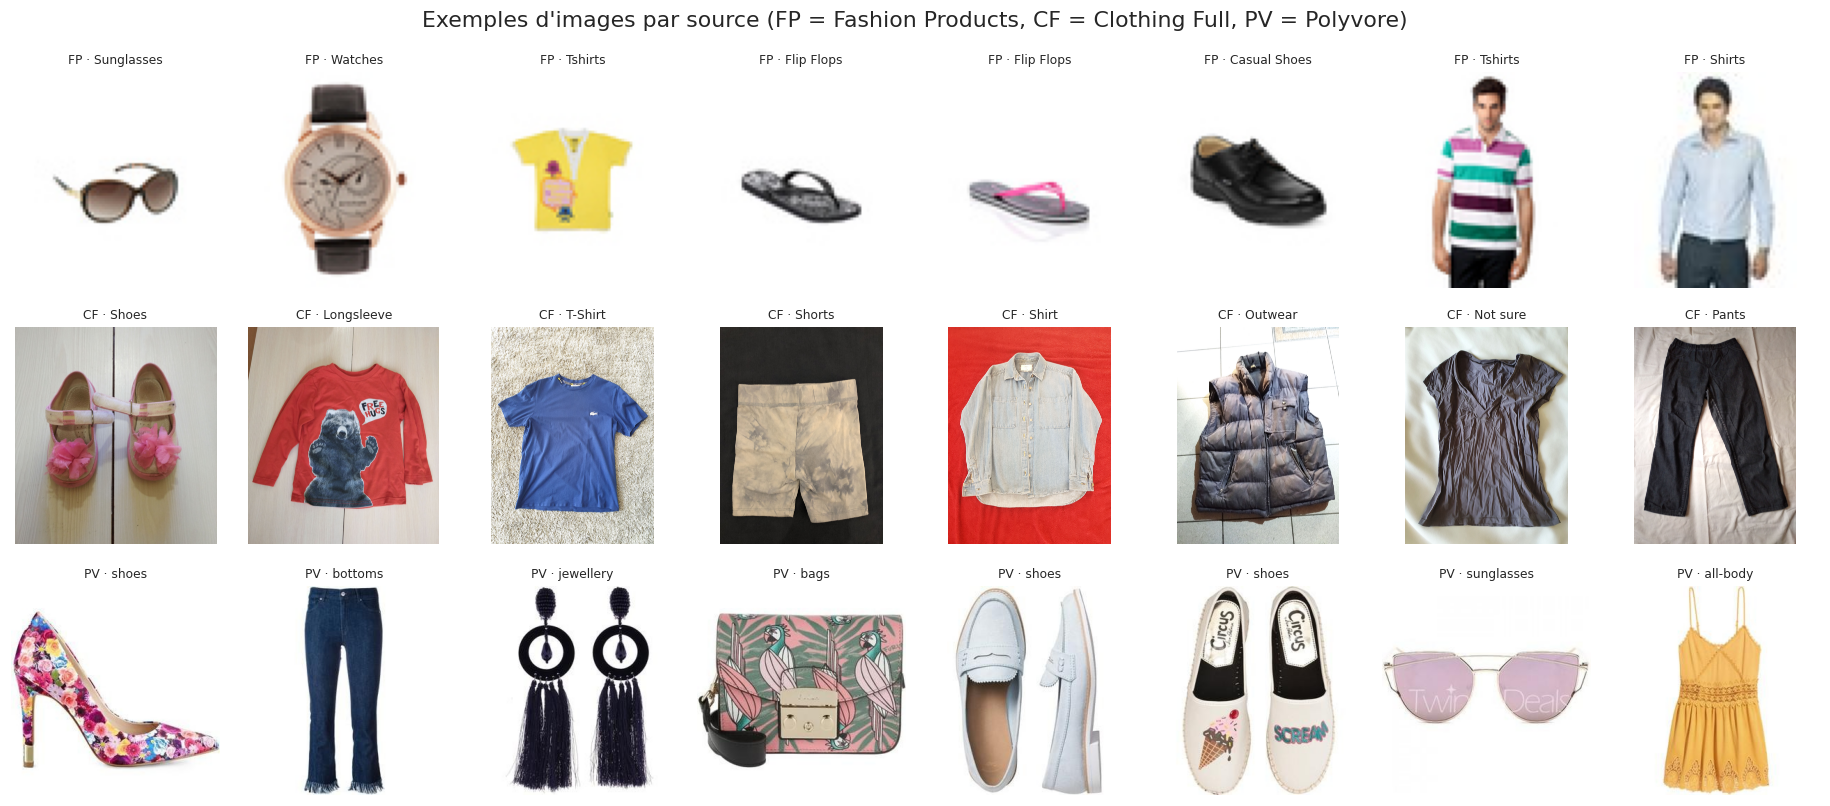

Figure enregistrée : /content/dressme/reports/figures/03_grille_exemples_sources.png


In [18]:
samples = []
if products is not None:
    subset = products[products["image_exists"]].sample(8, random_state=SEED)
    samples += list(zip(subset["image_path"], "FP · " + subset["articleType"].astype(str)))
if clothing is not None:
    subset = clothing[clothing["image_exists"]].sample(8, random_state=SEED)
    samples += list(zip(subset["image_path"], "CF · " + subset["label"].astype(str)))
if items is not None and items["image_path"].notna().any():
    subset = items[items["image_path"].notna()].sample(8, random_state=SEED)
    samples += list(zip(subset["image_path"], "PV · " + subset["category"].astype(str)))
image_grid(samples, "Exemples d'images par source (FP = Fashion Products, CF = Clothing Full, PV = Polyvore)",
           "03_grille_exemples_sources")

**Ce qu'on observe / Ce qu'on en conclut**

*À compléter après exécution, uniquement à partir des sorties ci-dessus :*
- différences visuelles entre sources (fond, cadrage, porté ou à plat)
- source la plus proche des futures photos utilisateur

## 4. Qualité des données

**Pourquoi on fait ça :** les valeurs manquantes et les textes vides limitent les attributs exploitables : il faut les mesurer colonne par colonne avant de décider quoi imputer ou retirer.

,source,colonne,manquantes,vides,pct_manquantes_ou_vides
6,polyvore_items,title,0,176156,70.18
16,fashion_products,usage,317,0,0.71
14,fashion_products,season,21,0,0.05
13,fashion_products,baseColour,15,0,0.03
17,fashion_products,productDisplayName,7,0,0.02


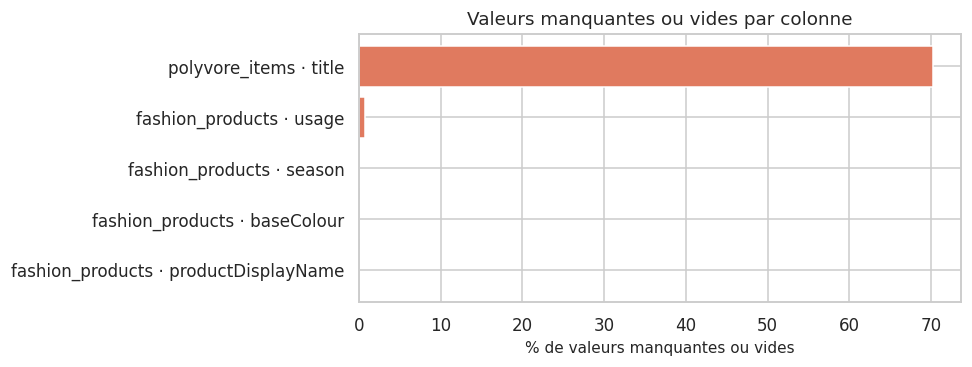

Figure enregistrée : /content/dressme/reports/figures/04_valeurs_manquantes.png


In [19]:
technical_columns = {"image_path", "image_exists", "in_image_shard"}
missing = pd.concat(
    [preprocessing.missing_report(df.drop(columns=[c for c in df.columns if c in technical_columns]), name)
     for name, df in DATASETS.items() if df is not None],
    ignore_index=True,
)
missing_nonzero = missing[missing["pct_manquantes_ou_vides"] > 0].sort_values("pct_manquantes_ou_vides", ascending=False)
display(missing_nonzero)

if len(missing_nonzero):
    fig, ax = plt.subplots(figsize=(9, 0.4 * len(missing_nonzero) + 1.5))
    labels = missing_nonzero["source"] + " · " + missing_nonzero["colonne"]
    ax.barh(labels, missing_nonzero["pct_manquantes_ou_vides"], color="#E07A5F")
    ax.invert_yaxis()
    ax.set_xlabel("% de valeurs manquantes ou vides")
    ax.set_title("Valeurs manquantes ou vides par colonne")
    save_fig(fig, "04_valeurs_manquantes")
else:
    print("Aucune valeur manquante ou vide.")

**Ce qu'on observe / Ce qu'on en conclut**

*À compléter après exécution, uniquement à partir des sorties ci-dessus :*
- colonnes les plus touchées et impact sur les objectifs (ex. saison / usage pour le contexte)
- décision : imputation (« inconnu ») ou retrait

**Pourquoi on fait ça :** les doublons faussent les statistiques et, surtout, créent des **fuites** entre train et test (le même produit des deux côtés du split).

In [20]:
duplicate_rows = []


def add_duplicate(source, check, count):
    duplicate_rows.append({"source": source, "contrôle": check, "nombre": int(count)})


if outfits is not None:
    add_duplicate("polyvore_outfits", "lignes (set_id, item_id) en double", outfits.duplicated(["set_id", "item_id"]).sum())
    outfit_signature = outfits.groupby("set_id")["item_id"].apply(lambda s: tuple(sorted(s)))
    add_duplicate("polyvore_outfits", "tenues au contenu identique à une autre", outfit_signature.duplicated().sum())
if items is not None:
    add_duplicate("polyvore_items", "item_id en double", items["item_id"].duplicated().sum())
    text = preprocessing.polyvore_text(items)
    add_duplicate("polyvore_items", "textes identiques (non vides)", text[text != ""].duplicated().sum())
if products is not None:
    add_duplicate("fashion_products", "id en double", products["id"].duplicated().sum())
    names = preprocessing.normalize_name(products["productDisplayName"])
    add_duplicate("fashion_products", "noms produit identiques (non vides)", names[names != ""].duplicated().sum())
if clothing is not None:
    add_duplicate("clothing_full", "image en double", clothing["image"].duplicated().sum())
duplicates = pd.DataFrame(duplicate_rows)
display(duplicates)

,source,contrôle,nombre
0,polyvore_outfits,"lignes (set_id, item_id) en double",24
1,polyvore_outfits,tenues au contenu identique à une autre,13
2,polyvore_items,item_id en double,0
3,polyvore_items,textes identiques (non vides),26855
4,fashion_products,id en double,0
5,fashion_products,noms produit identiques (non vides),13530
6,clothing_full,image en double,0


**Ce qu'on observe / Ce qu'on en conclut**

*À compléter après exécution, uniquement à partir des sorties ci-dessus :*
- ampleur des doublons exacts et des quasi-doublons (même nom produit)
- conséquence pour le split : regrouper par nom produit

**Pourquoi on fait ça :** une image absente ou corrompue fait planter l'entraînement ou le calcul d'embeddings. On ouvre chaque image (`check_images`) : existence, lisibilité, dimensions. Compter plusieurs minutes pour Fashion Products.

In [21]:
def run_image_checks(df, label):
    subset = df
    if IMAGE_CHECK_LIMIT is not None and len(df) > IMAGE_CHECK_LIMIT:
        subset = df.sample(IMAGE_CHECK_LIMIT, random_state=SEED)
    started = time.time()
    checks = preprocessing.check_images(subset["image_path"])
    print(f"{label} : {len(checks)} images vérifiées en {time.time() - started:.0f} s")
    return checks


image_checks = {}
if products is not None:
    image_checks["fashion_products"] = run_image_checks(products, "Fashion Products")
if clothing is not None:
    image_checks["clothing_full"] = run_image_checks(clothing, "Clothing Full")
if items is not None and items["image_path"].notna().any():
    image_checks["polyvore_items"] = run_image_checks(items[items["image_path"].notna()], "Polyvore (échantillon extrait)")

image_quality = pd.DataFrame([
    {"source": name, "vérifiées": len(checks), "lisibles": int(checks["image_ok"].sum()),
     "absentes": int((checks["problem"] == "absente").sum()),
     "illisibles": int(checks["problem"].fillna("").str.startswith("illisible").sum())}
    for name, checks in image_checks.items()
])
display(image_quality)
for name, checks in image_checks.items():
    problems = checks[~checks["image_ok"]]
    if len(problems):
        print(f"\n{name} : exemples de problèmes")
        display(problems.head())

Fashion Products : 44424 images vérifiées en 337 s
Clothing Full : 5403 images vérifiées en 7 s
Polyvore (échantillon extrait) : 5000 images vérifiées en 1 s


,source,vérifiées,lisibles,absentes,illisibles
0,fashion_products,44424,44419,5,0
1,clothing_full,5403,5403,0,0
2,polyvore_items,5000,5000,0,0



fashion_products : exemples de problèmes


,image_ok,problem,width,height,mode
6695,False,absente,NaN,NaN,NaN
16194,False,absente,NaN,NaN,NaN
32309,False,absente,NaN,NaN,NaN
36381,False,absente,NaN,NaN,NaN
40000,False,absente,NaN,NaN,NaN


**Ce qu'on observe / Ce qu'on en conclut**

*À compléter après exécution, uniquement à partir des sorties ci-dessus :*
- nombre d'images absentes ou illisibles par source
- lignes à retirer lors de la transformation

**Pourquoi on fait ça :** le notebook 00 a montré plus d'images que de lignes dans Clothing Full. On identifie précisément ces images sans label, et les éventuelles lignes sans image.

,constat,nombre
0,images sur disque sans ligne dans images.csv,359
1,lignes du CSV sans image,0
2,images présentes dans les deux,5403


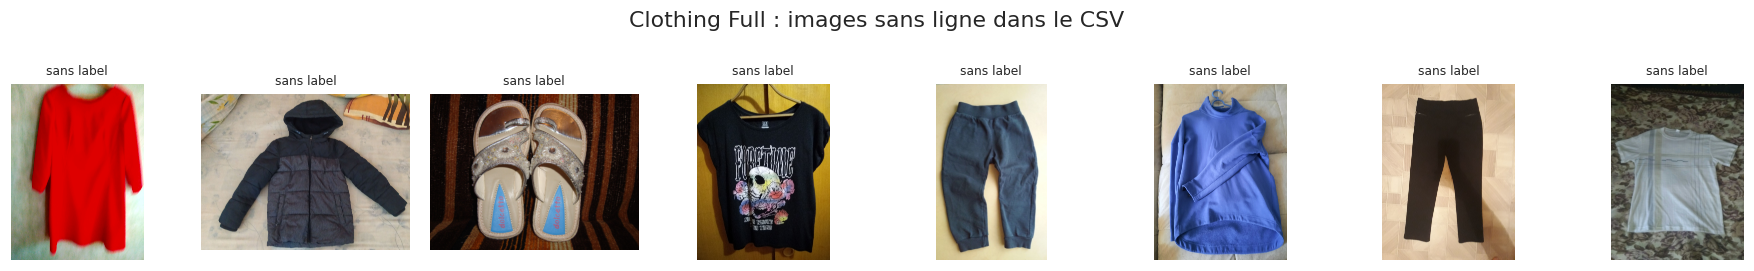

Figure enregistrée : /content/dressme/reports/figures/04_clothing_images_sans_label.png


In [22]:
if clothing is not None:
    image_dir = Path(clothing_info["image_dir"])
    on_disk = {p.stem for p in image_dir.iterdir() if p.suffix.lower() in data_loading.IMAGE_EXTENSIONS}
    in_csv = set(clothing["image"].astype(str))
    orphan_images = sorted(on_disk - in_csv)
    clothing_gap = pd.DataFrame({
        "constat": ["images sur disque sans ligne dans images.csv", "lignes du CSV sans image",
                    "images présentes dans les deux"],
        "nombre": [len(orphan_images), len(in_csv - on_disk), len(on_disk & in_csv)],
    })
    display(clothing_gap)
    image_grid([(image_dir / f"{stem}.jpg", "sans label") for stem in orphan_images[:8]],
               "Clothing Full : images sans ligne dans le CSV", "04_clothing_images_sans_label")
else:
    print("Clothing Full absent.")

**Ce qu'on observe / Ce qu'on en conclut**

*À compléter après exécution, uniquement à partir des sorties ci-dessus :*
- nombre d'images sans label et ce qu'elles représentent visuellement
- décision : exclues (pas de vérité terrain) ou candidates à un étiquetage ultérieur

**Pourquoi on fait ça :** beaucoup de titres Polyvore sont vides ; `url_name` sert de secours. On mesure combien d'articles n'ont **aucun** texte exploitable, par catégorie.

,constat,nombre,pourcentage
0,titre vide,176156,70.18
1,url_name vide,0,0.00
2,titre ET url_name vides (aucun texte),0,0.00


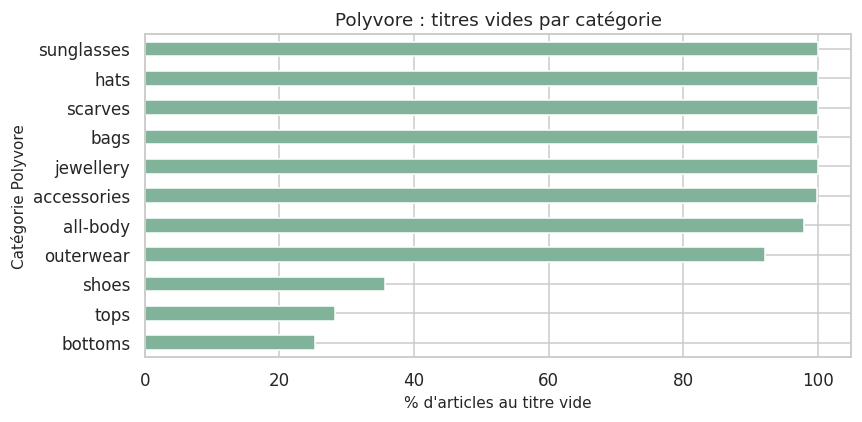

Figure enregistrée : /content/dressme/reports/figures/04_polyvore_titres_vides.png


In [23]:
if items is not None:
    blank_title = preprocessing.is_blank(items["title"])
    blank_url = preprocessing.is_blank(items["url_name"])
    title_summary = pd.DataFrame({
        "constat": ["titre vide", "url_name vide", "titre ET url_name vides (aucun texte)"],
        "nombre": [int(blank_title.sum()), int(blank_url.sum()), int((blank_title & blank_url).sum())],
    })
    title_summary["pourcentage"] = (100 * title_summary["nombre"] / len(items)).round(2)
    display(title_summary)

    per_category = (items.assign(titre_vide=blank_title).groupby("category")["titre_vide"].mean() * 100).sort_values()
    fig, ax = plt.subplots(figsize=(8, 4))
    per_category.plot.barh(ax=ax, color="#81B29A")
    ax.set_xlabel("% d'articles au titre vide")
    ax.set_ylabel("Catégorie Polyvore")
    ax.set_title("Polyvore : titres vides par catégorie")
    save_fig(fig, "04_polyvore_titres_vides")
else:
    print("Polyvore items absent.")

**Ce qu'on observe / Ce qu'on en conclut**

*À compléter après exécution, uniquement à partir des sorties ci-dessus :*
- part des titres vides, catégories les plus touchées
- part d'articles sans aucun texte après repli sur url_name

**Pourquoi on fait ça :** des valeurs incohérentes (années atypiques, types d'article classés dans plusieurs sous-catégories, articles de tenues sans métadonnées, proportions d'images extrêmes) signalent des erreurs à corriger.

In [24]:
if products is not None:
    print("Fashion Products — années (valeurs manquantes incluses) :")
    display(products["year"].value_counts(dropna=False).sort_index().to_frame("n_produits").T)
    q1, q3 = products["year"].quantile([0.25, 0.75])
    iqr = q3 - q1
    year_outliers = products[(products["year"] < q1 - 1.5 * iqr) | (products["year"] > q3 + 1.5 * iqr)]
    print(f"Années atypiques (règle 1,5 × IQR) : {len(year_outliers)}")

    multi_sub = products.groupby("articleType")["subCategory"].nunique()
    print("articleType rattachés à plusieurs subCategory :", list(multi_sub[multi_sub > 1].index))
    print("\nGenre × masterCategory :")
    display(pd.crosstab(products["gender"], products["masterCategory"]))

if clothing is not None:
    print("Clothing Full — part de vêtements enfant par label (%) :")
    display((clothing.groupby("label")["kids"].mean() * 100).round(1).sort_values(ascending=False).to_frame("%_kids").T)

if outfits is not None and items is not None:
    outfit_items = set(outfits["item_id"])
    metadata_items = set(items["item_id"])
    print("Articles des tenues absents des métadonnées :", len(outfit_items - metadata_items))
    print("Articles des métadonnées absents des tenues :", len(metadata_items - outfit_items))

size_rows = []
for name, checks in image_checks.items():
    ok = checks[checks["image_ok"]].copy()
    if not len(ok):
        continue
    ok["ratio"] = ok["width"] / ok["height"]
    q1, q3 = ok["ratio"].quantile([0.25, 0.75])
    iqr = q3 - q1
    size_rows.append({"source": name, "images": len(ok),
                      "ratio_médian": round(ok["ratio"].median(), 3),
                      "ratios_atypiques_1.5IQR": int(((ok["ratio"] < q1 - 1.5 * iqr) | (ok["ratio"] > q3 + 1.5 * iqr)).sum()),
                      "largeur_min": int(ok["width"].min()), "largeur_max": int(ok["width"].max())})
if size_rows:
    print("\nProportions d'image (largeur / hauteur) :")
    display(pd.DataFrame(size_rows))

Fashion Products — années (valeurs manquantes incluses) :


year,2007.0,2008.0,2009.0,2010.0,2011.0,2012.0,2013.0,2014.0,2015.0,2016.0,2017.0,2018.0,2019.0,NaN
n_produits,2,7,20,846,13672,16288,1212,236,2780,6006,2916,405,33,1


Années atypiques (règle 1,5 × IQR) : 0
articleType rattachés à plusieurs subCategory : ['Backpacks', 'Belts', 'Body Lotion', 'Clutches', 'Dresses', 'Eyeshadow', 'Face Moisturisers', 'Face Scrub and Exfoliator', 'Flip Flops', 'Handbags', 'Kajal and Eyeliner', 'Laptop Bag', 'Mask and Peel', 'Messenger Bag', 'Perfume and Body Mist', 'Sandals', 'Scarves', 'Shorts', 'Swimwear', 'Ties', 'Travel Accessory', 'Tshirts', 'Wallets', 'Water Bottle', 'Wristbands']

Genre × masterCategory :


masterCategory,Accessories,Apparel,Footwear,Free Items,Home,Personal Care,Sporting Goods
gender,,,,,,,
Boys,17,759,54,0,0,0,0
Girls,28,567,60,0,0,0,0
Men,4412,11352,5751,53,0,579,0
Unisex,1497,96,518,9,1,15,25
Women,5320,8623,2836,43,0,1809,0


Clothing Full — part de vêtements enfant par label (%) :


label,Body,Other,Shoes,Dress,Undershirt,Pants,Top,Outwear,Skip,Shorts,Hat,Longsleeve,Skirt,Polo,Not sure,Hoodie,T-Shirt,Blazer,Shirt,Blouse
%_kids,98.6,41.8,13.9,13.4,12.7,12.6,11.6,11.2,8.3,7.8,5.8,5.4,4.5,4.2,3.1,3.0,2.7,1.8,1.6,0.0


Articles des tenues absents des métadonnées : 0
Articles des métadonnées absents des tenues : 0

Proportions d'image (largeur / hauteur) :


,source,images,ratio_médian,ratios_atypiques_1.5IQR,largeur_min,largeur_max
0,fashion_products,44419,0.75,23,53,60
1,clothing_full,5403,0.75,1268,309,6528
2,polyvore_items,5000,1.00,0,300,300


**Ce qu'on observe / Ce qu'on en conclut**

*À compléter après exécution, uniquement à partir des sorties ci-dessus :*
- incohérences réelles détectées et leur volume
- outliers d'années ou de proportions d'image à conserver ou retirer

**Pourquoi on fait ça :** un fort déséquilibre de classes biaise un classifieur vers les classes majoritaires : il faut le quantifier pour choisir métriques (F1 macro) et stratégie (stratification, pondération).

,source,colonne,classes,classe_majoritaire,effectif_max,effectif_min,ratio_max_min,part_majoritaire_%
0,fashion_products,articleType,143,Tshirts,7067,1,7067.0,15.9
1,fashion_products,masterCategory,7,Apparel,21397,1,21397.0,48.2
2,clothing_full,label,20,T-Shirt,1011,12,84.2,18.7
3,polyvore_items,category,11,shoes,44850,4898,9.2,17.9


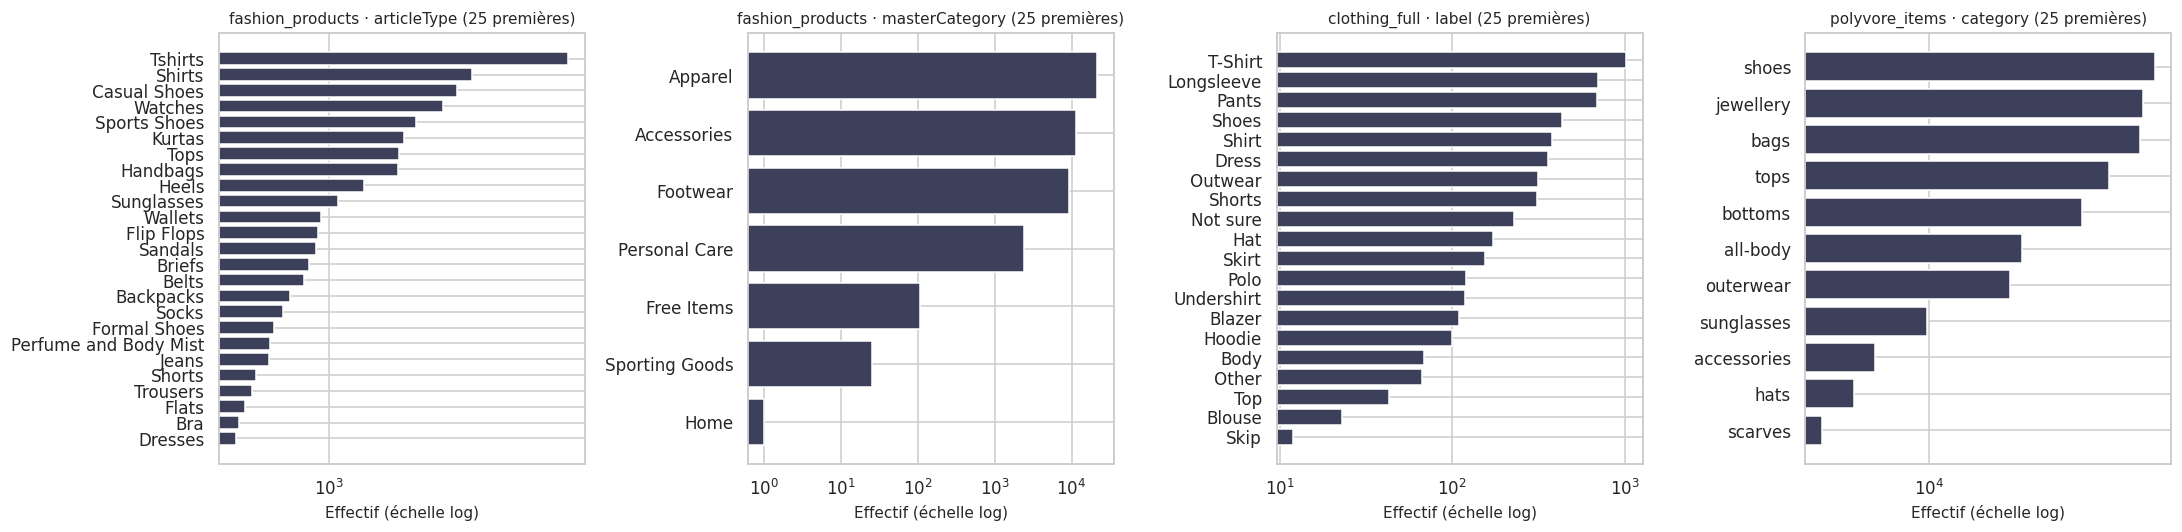

Figure enregistrée : /content/dressme/reports/figures/04_desequilibre_classes.png


In [25]:
label_columns = [("fashion_products", products, "articleType"), ("fashion_products", products, "masterCategory"),
                 ("clothing_full", clothing, "label"), ("polyvore_items", items, "category")]
imbalance_rows = []
plotted = [(source, df, column) for source, df, column in label_columns if df is not None]
for source, df, column in plotted:
    counts = df[column].value_counts()
    imbalance_rows.append({"source": source, "colonne": column, "classes": len(counts),
                           "classe_majoritaire": counts.index[0], "effectif_max": int(counts.iloc[0]),
                           "effectif_min": int(counts.iloc[-1]),
                           "ratio_max_min": round(counts.iloc[0] / counts.iloc[-1], 1),
                           "part_majoritaire_%": round(100 * counts.iloc[0] / counts.sum(), 1)})
display(pd.DataFrame(imbalance_rows))

if plotted:
    fig, axes = plt.subplots(1, len(plotted), figsize=(5 * len(plotted), 5), squeeze=False)
    for ax, (source, df, column) in zip(axes.flat, plotted):
        counts = df[column].value_counts().head(25)
        ax.barh(counts.index.astype(str), counts.values, color="#3D405B")
        ax.invert_yaxis()
        ax.set_xscale("log")
        ax.set_xlabel("Effectif (échelle log)")
        ax.set_title(f"{source} · {column} (25 premières)", fontsize=10)
    save_fig(fig, "04_desequilibre_classes")

**Ce qu'on observe / Ce qu'on en conclut**

*À compléter après exécution, uniquement à partir des sorties ci-dessus :*
- ratio entre classe la plus et la moins fréquente, par source
- classes trop rares pour être apprises (exclues du split si < 10 exemples)

## 5. Analyse exploratoire (EDA)

**Pourquoi on fait ça :** Fashion Products est la source la plus riche en attributs (catégorie, couleur, saison, usage, genre, année) : ses distributions indiquent quels attributs DressMe pourra prédire de façon fiable.

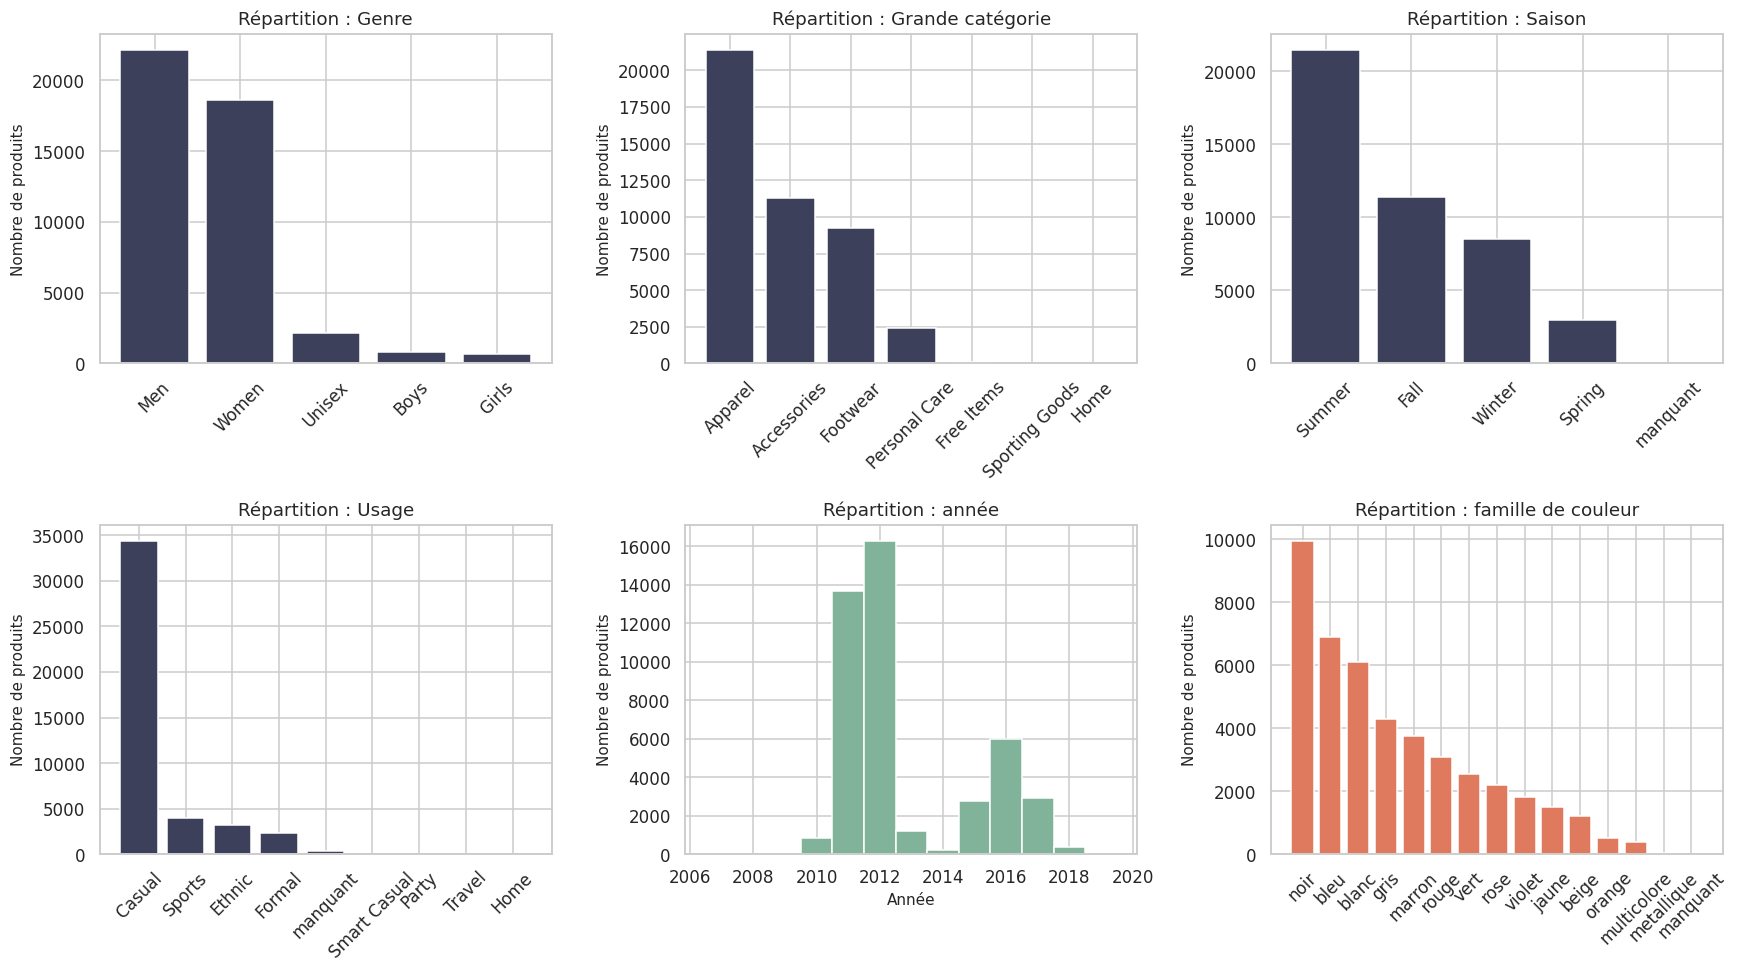

Figure enregistrée : /content/dressme/reports/figures/05_fp_distributions.png


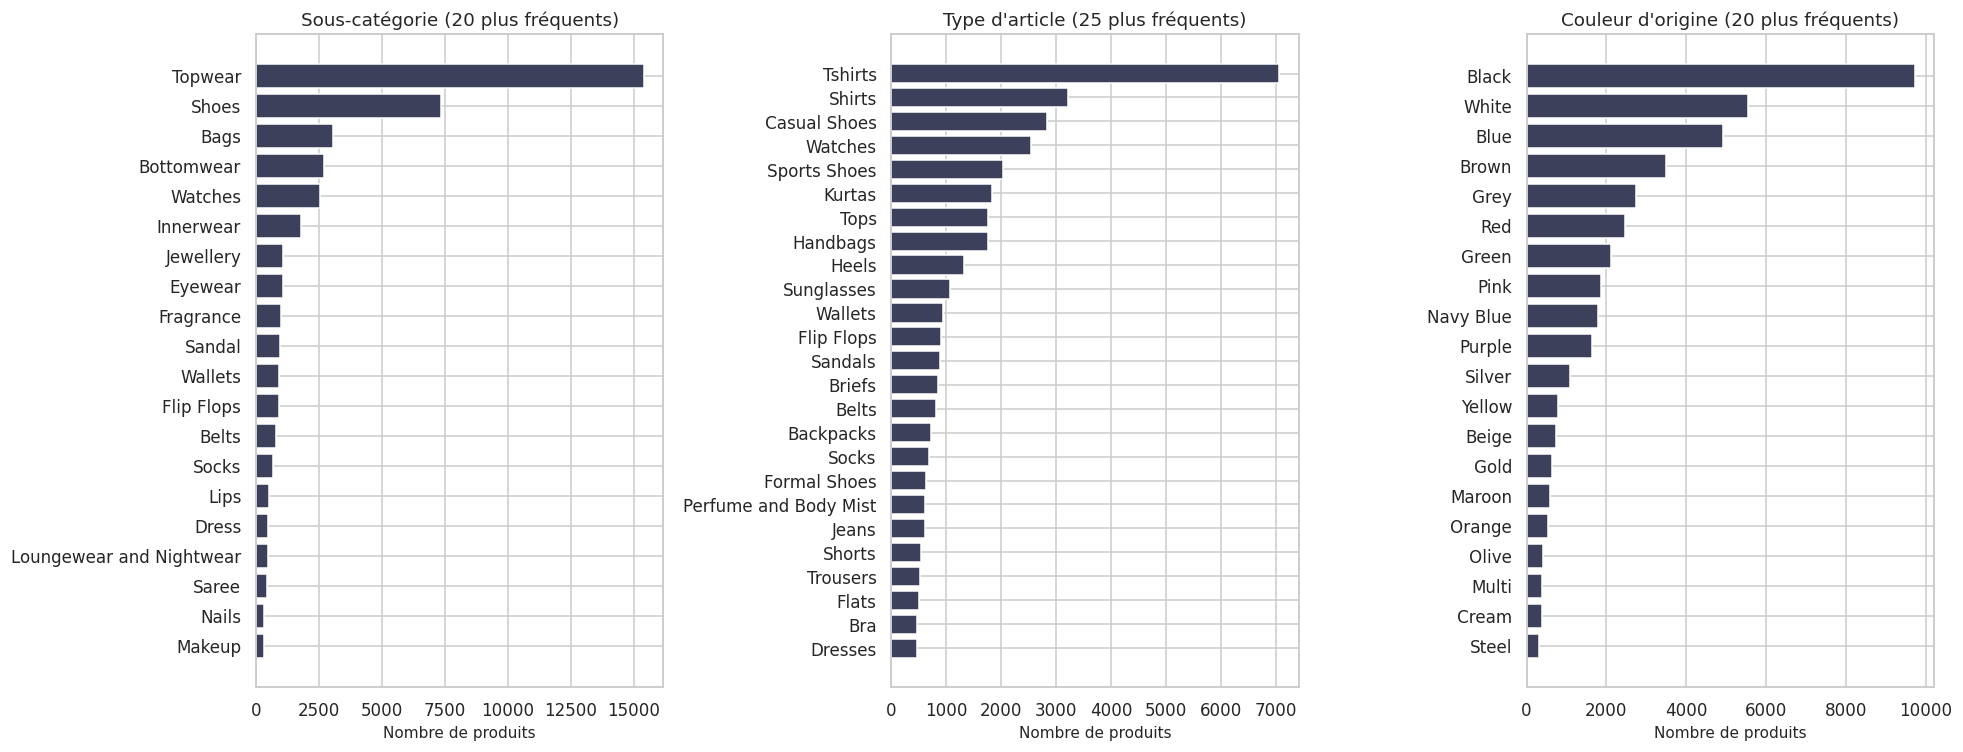

Figure enregistrée : /content/dressme/reports/figures/05_fp_top_categories_couleurs.png


In [26]:
if products is not None:
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    for ax, column, title in zip(axes.flat[:4], ["gender", "masterCategory", "season", "usage"],
                                 ["Genre", "Grande catégorie", "Saison", "Usage"]):
        counts = products[column].fillna("manquant").value_counts()
        ax.bar(counts.index.astype(str), counts.values, color="#3D405B")
        ax.set_title(f"Répartition : {title}")
        ax.set_ylabel("Nombre de produits")
        ax.tick_params(axis="x", rotation=45)
    years = products["year"].dropna()
    axes.flat[4].hist(years, bins=np.arange(years.min(), years.max() + 2) - 0.5, color="#81B29A")
    axes.flat[4].set_title("Répartition : année")
    axes.flat[4].set_xlabel("Année")
    axes.flat[4].set_ylabel("Nombre de produits")
    families = products["baseColour"].map(preprocessing.normalize_color).fillna("manquant").value_counts()
    axes.flat[5].bar(families.index, families.values, color="#E07A5F")
    axes.flat[5].set_title("Répartition : famille de couleur")
    axes.flat[5].set_ylabel("Nombre de produits")
    axes.flat[5].tick_params(axis="x", rotation=45)
    save_fig(fig, "05_fp_distributions")

    fig, axes = plt.subplots(1, 3, figsize=(18, 7))
    for ax, column, n, title in zip(axes, ["subCategory", "articleType", "baseColour"], [20, 25, 20],
                                    ["Sous-catégorie", "Type d'article", "Couleur d'origine"]):
        counts = products[column].value_counts().head(n)
        ax.barh(counts.index.astype(str), counts.values, color="#3D405B")
        ax.invert_yaxis()
        ax.set_title(f"{title} ({n} plus fréquents)")
        ax.set_xlabel("Nombre de produits")
    save_fig(fig, "05_fp_top_categories_couleurs")
else:
    print("Fashion Products absent.")

**Ce qu'on observe / Ce qu'on en conclut**

*À compléter après exécution, uniquement à partir des sorties ci-dessus :*
- modalités dominantes et rares pour chaque attribut
- biais visibles (genre, années, usage) et part de couleurs classées « autre »

**Pourquoi on fait ça :** les croisements usage × saison et catégorie × couleur sont la base des règles de contexte (obj. 4) et d'harmonie de tenue (obj. 5) : ils montrent quelles associations sont fréquentes dans les données.

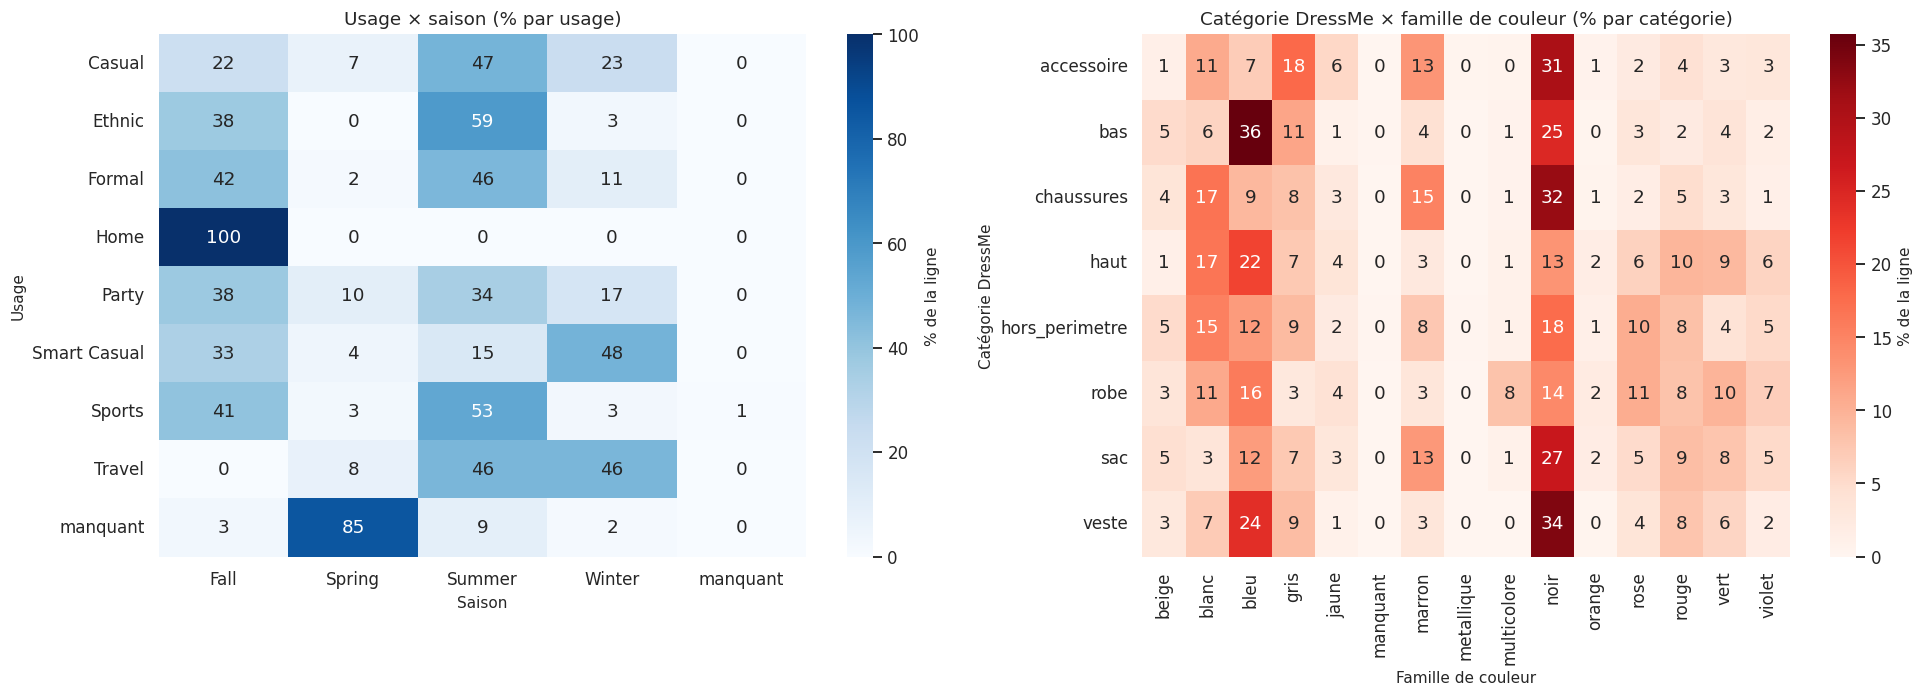

Figure enregistrée : /content/dressme/reports/figures/05_fp_croisements.png


In [27]:
if products is not None:
    eda = products.assign(
        dressme_category=preprocessing.map_fashion_products(products),
        color_family=products["baseColour"].map(preprocessing.normalize_color).fillna("manquant"),
    )
    fig, axes = plt.subplots(1, 2, figsize=(18, 6.5))
    usage_season = pd.crosstab(eda["usage"].fillna("manquant"), eda["season"].fillna("manquant"), normalize="index") * 100
    sns.heatmap(usage_season, annot=True, fmt=".0f", cmap="Blues", ax=axes[0], cbar_kws={"label": "% de la ligne"})
    axes[0].set_title("Usage × saison (% par usage)")
    axes[0].set_xlabel("Saison")
    axes[0].set_ylabel("Usage")
    category_color = pd.crosstab(eda["dressme_category"], eda["color_family"], normalize="index") * 100
    sns.heatmap(category_color, annot=True, fmt=".0f", cmap="Reds", ax=axes[1], cbar_kws={"label": "% de la ligne"})
    axes[1].set_title("Catégorie DressMe × famille de couleur (% par catégorie)")
    axes[1].set_xlabel("Famille de couleur")
    axes[1].set_ylabel("Catégorie DressMe")
    save_fig(fig, "05_fp_croisements")

**Ce qu'on observe / Ce qu'on en conclut**

*À compléter après exécution, uniquement à partir des sorties ci-dessus :*
- usages fortement liés à une saison
- couleurs dominantes par catégorie DressMe

**Pourquoi on fait ça :** la taille des images conditionne le prétraitement (redimensionnement à 224 px pour FashionCLIP) et révèle des différences entre sources (petites images studio contre grandes photos amateurs).

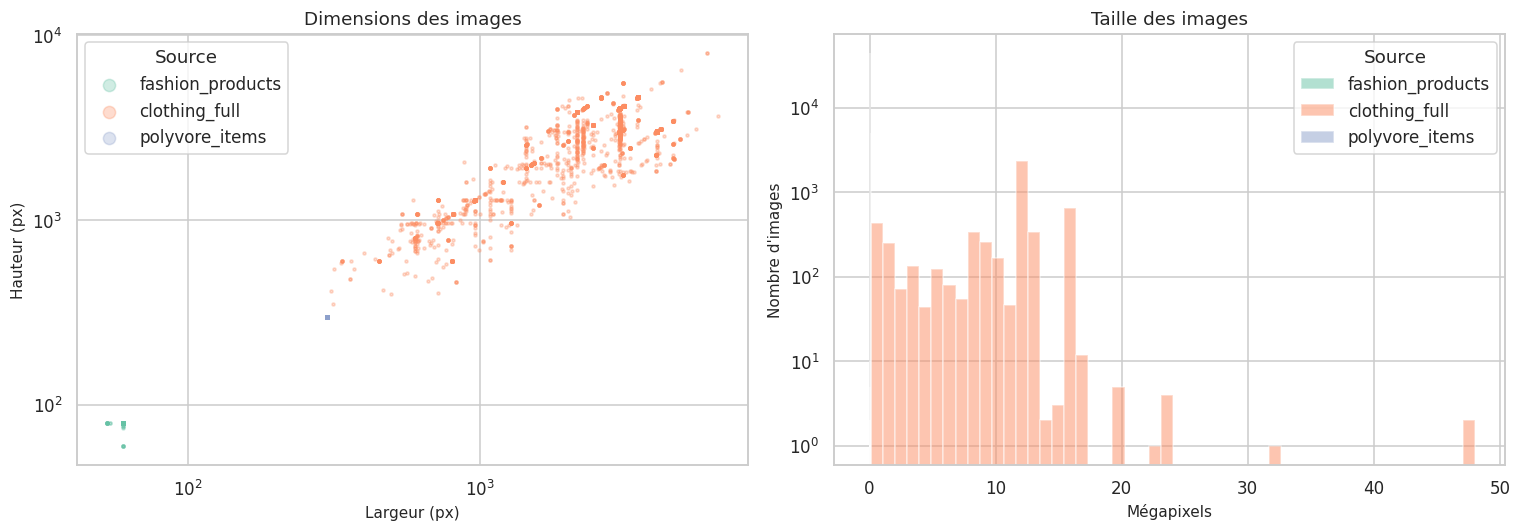

Figure enregistrée : /content/dressme/reports/figures/05_tailles_images.png


fashion_products          clothing_full         polyvore_items        
                 width   height         width  height          width  height
count          44419.0  44419.0        5403.0  5403.0         5000.0  5000.0
mean              60.0     80.0        2778.0  3371.0          300.0   300.0
std                0.0      0.0         929.0  1134.0            0.0     0.0
min               53.0     60.0         309.0   353.0          300.0   300.0
25%               60.0     80.0        2448.0  3000.0          300.0   300.0
50%               60.0     80.0        3016.0  4000.0          300.0   300.0
75%               60.0     80.0        3120.0  4032.0          300.0   300.0
max               60.0     80.0        6528.0  8000.0          300.0   300.0

In [28]:
if image_checks:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for name, checks in image_checks.items():
        ok = checks[checks["image_ok"]]
        axes[0].scatter(ok["width"], ok["height"], s=4, alpha=0.3, label=name)
        axes[1].hist(ok["width"] * ok["height"] / 1e6, bins=50, alpha=0.5, label=name)
    axes[0].set_title("Dimensions des images")
    axes[0].set_xlabel("Largeur (px)")
    axes[0].set_ylabel("Hauteur (px)")
    axes[0].set_xscale("log")
    axes[0].set_yscale("log")
    axes[0].legend(title="Source", markerscale=4)
    axes[1].set_title("Taille des images")
    axes[1].set_xlabel("Mégapixels")
    axes[1].set_ylabel("Nombre d'images")
    axes[1].set_yscale("log")
    axes[1].legend(title="Source")
    save_fig(fig, "05_tailles_images")
    display(pd.concat({name: c.loc[c["image_ok"], ["width", "height"]].describe() for name, c in image_checks.items()}, axis=1).round(0))

**Ce qu'on observe / Ce qu'on en conclut**

*À compléter après exécution, uniquement à partir des sorties ci-dessus :*
- écart de résolution entre sources
- conséquences pour le prétraitement et le stockage

**Pourquoi on fait ça :** Clothing Full est la source la plus proche des photos de garde-robe réelles. On regarde ses labels et le nombre de photos par personne, car une même personne photographie souvent dans le même décor : c'est pourquoi le split est fait par `sender_id`.

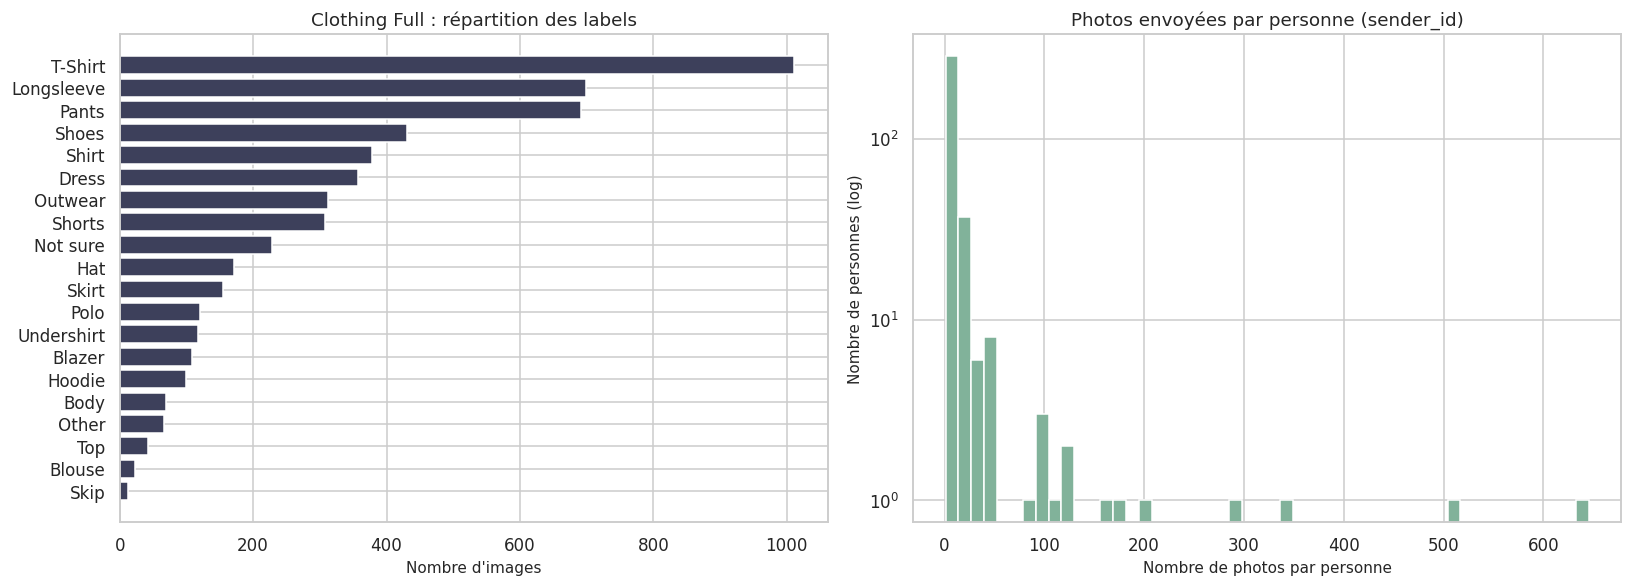

Figure enregistrée : /content/dressme/reports/figures/05_clothing_labels_senders.png
Personnes distinctes : 351 | médiane de photos par personne : 4.0


In [29]:
if clothing is not None:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
    counts = clothing["label"].value_counts()
    axes[0].barh(counts.index, counts.values, color="#3D405B")
    axes[0].invert_yaxis()
    axes[0].set_title("Clothing Full : répartition des labels")
    axes[0].set_xlabel("Nombre d'images")
    per_sender = clothing["sender_id"].value_counts()
    axes[1].hist(per_sender.values, bins=50, color="#81B29A")
    axes[1].set_yscale("log")
    axes[1].set_title("Photos envoyées par personne (sender_id)")
    axes[1].set_xlabel("Nombre de photos par personne")
    axes[1].set_ylabel("Nombre de personnes (log)")
    save_fig(fig, "05_clothing_labels_senders")
    print("Personnes distinctes :", clothing["sender_id"].nunique(),
          "| médiane de photos par personne :", per_sender.median())
else:
    print("Clothing Full absent.")

**Ce qu'on observe / Ce qu'on en conclut**

*À compléter après exécution, uniquement à partir des sorties ci-dessus :*
- labels majoritaires et labels inexploitables (Not sure, Other, Skip)
- concentration des photos sur quelques personnes

## 6. Analyse Polyvore (tenues)

**Pourquoi on fait ça :** Polyvore est la seule source qui décrit des **tenues complètes** composées par des utilisateurs : c'est la base de la compatibilité (obj. 5) et de la détection des manques (obj. 6). On commence par la taille des tenues.

,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
test,10000.0,5.35,1.62,2.0,4.0,5.0,6.0,17.0
train,53306.0,5.34,1.60,2.0,4.0,5.0,6.0,19.0
valid,5000.0,5.36,1.62,2.0,4.0,5.0,6.0,14.0


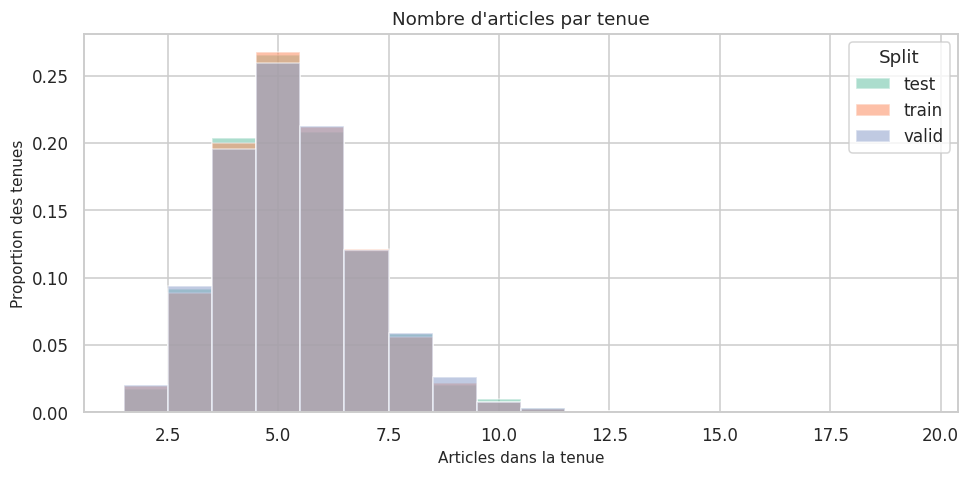

Figure enregistrée : /content/dressme/reports/figures/06_polyvore_articles_par_tenue.png


In [30]:
if outfits is not None:
    outfit_sizes = outfits.groupby(["split", "set_id"]).size().rename("n_items").reset_index()
    display(outfit_sizes.groupby("split")["n_items"].describe().round(2))
    fig, ax = plt.subplots(figsize=(9, 4.5))
    bins = np.arange(outfit_sizes["n_items"].min(), outfit_sizes["n_items"].max() + 2) - 0.5
    for split_name, group in outfit_sizes.groupby("split"):
        ax.hist(group["n_items"], bins=bins, alpha=0.55, density=True, label=split_name)
    ax.set_title("Nombre d'articles par tenue")
    ax.set_xlabel("Articles dans la tenue")
    ax.set_ylabel("Proportion des tenues")
    ax.legend(title="Split")
    save_fig(fig, "06_polyvore_articles_par_tenue")
else:
    print("Polyvore Outfits absent.")

**Ce qu'on observe / Ce qu'on en conclut**

*À compléter après exécution, uniquement à partir des sorties ci-dessus :*
- taille typique d'une tenue, différences entre splits

**Pourquoi on fait ça :** les combinaisons de catégories les plus fréquentes décrivent ce qu'est une tenue « complète » ; une garde-robe à laquelle il manque une catégorie clé de ces combinaisons présente un manque (obj. 6).

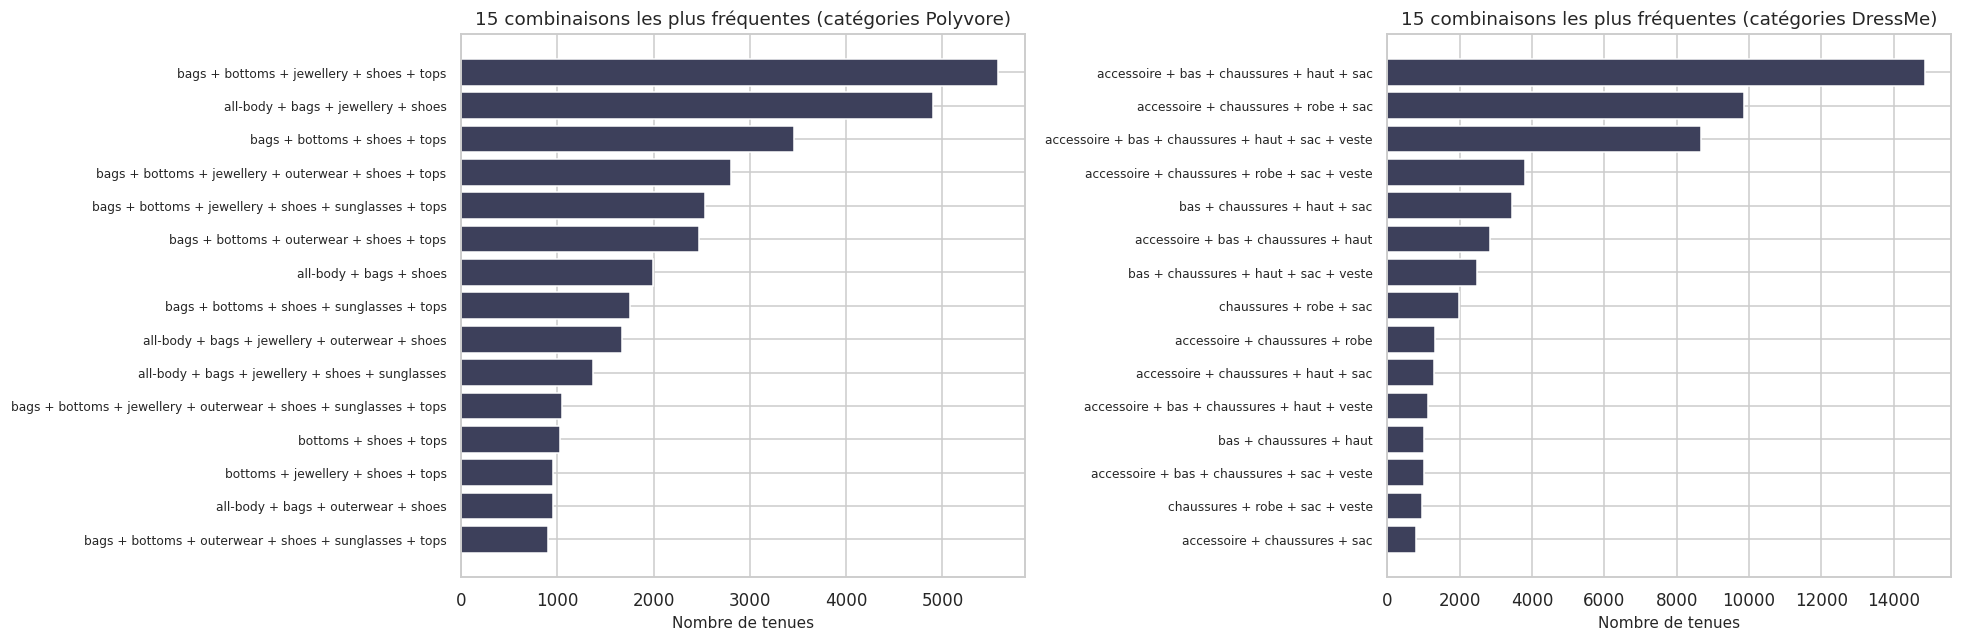

Figure enregistrée : /content/dressme/reports/figures/06_polyvore_combinaisons.png


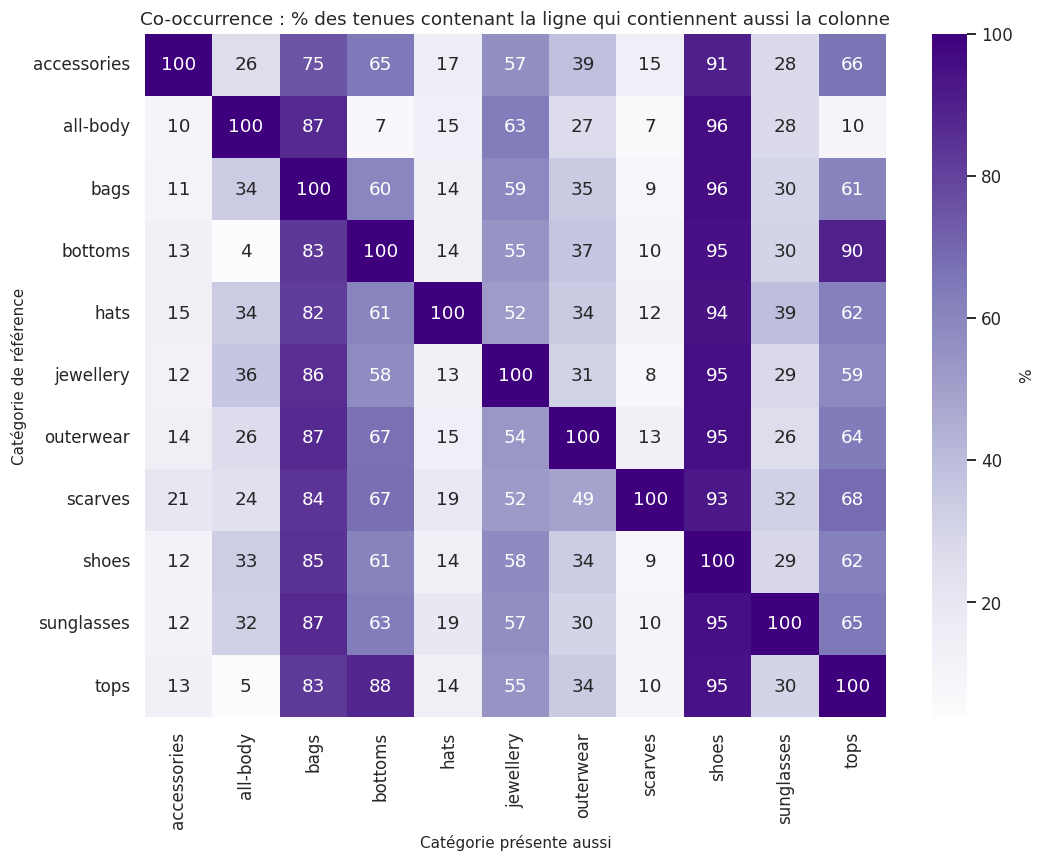

Figure enregistrée : /content/dressme/reports/figures/06_polyvore_cooccurrence.png


In [31]:
if outfits is not None and items is not None:
    outfit_items = outfits.merge(items[["item_id", "category"]], on="item_id", how="left")
    outfit_items["category"] = outfit_items["category"].fillna("inconnue")
    outfit_items["dressme_category"] = outfit_items["category"].str.lower().map(preprocessing.POLYVORE_CATEGORY_TO_DRESSME).fillna(OUT_OF_SCOPE)

    combos = outfit_items.groupby("set_id")["category"].agg(lambda s: " + ".join(sorted(set(s))))
    coarse = outfit_items.groupby("set_id")["dressme_category"].agg(lambda s: " + ".join(sorted(set(s))))
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    for ax, series, title in ((axes[0], combos, "catégories Polyvore"), (axes[1], coarse, "catégories DressMe")):
        top = series.value_counts().head(15)
        ax.barh(top.index, top.values, color="#3D405B")
        ax.invert_yaxis()
        ax.set_title(f"15 combinaisons les plus fréquentes ({title})")
        ax.set_xlabel("Nombre de tenues")
        ax.tick_params(axis="y", labelsize=8)
    save_fig(fig, "06_polyvore_combinaisons")

    presence = pd.crosstab(outfit_items["set_id"], outfit_items["category"]).clip(upper=1)
    co_occurrence = presence.T @ presence
    conditional = co_occurrence.div(np.diag(co_occurrence), axis=0) * 100
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(conditional, annot=True, fmt=".0f", cmap="Purples", ax=ax, cbar_kws={"label": "%"})
    ax.set_title("Co-occurrence : % des tenues contenant la ligne qui contiennent aussi la colonne")
    ax.set_xlabel("Catégorie présente aussi")
    ax.set_ylabel("Catégorie de référence")
    save_fig(fig, "06_polyvore_cooccurrence")

**Ce qu'on observe / Ce qu'on en conclut**

*À compléter après exécution, uniquement à partir des sorties ci-dessus :*
- structures de tenues dominantes (ex. haut + bas + chaussures + sac)
- catégories presque toujours associées (co-occurrence élevée)

**Pourquoi on fait ça :** dans la version « nondisjoint », un article peut apparaître dans plusieurs tenues et plusieurs splits. Il faut le savoir pour interpréter les scores et éviter une fuite au niveau des articles.

,count,mean,std,min,25%,50%,75%,max
tenues_par_article,251008.0,1.45,1.69,1.0,1.0,1.0,1.0,241.0


Articles présents dans plusieurs splits (propriété de la version « nondisjoint ») : 23596


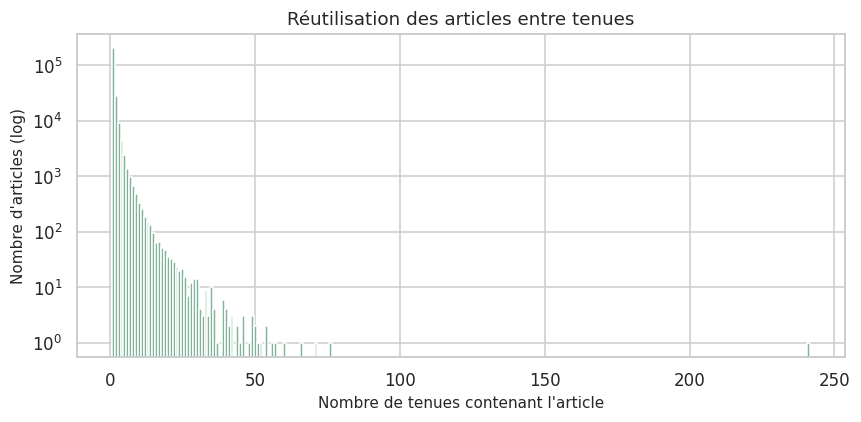

Figure enregistrée : /content/dressme/reports/figures/06_polyvore_reutilisation_articles.png


In [32]:
if outfits is not None:
    reuse = outfits.groupby("item_id")["set_id"].nunique()
    splits_per_item = outfits.groupby("item_id")["split"].nunique()
    display(reuse.describe().round(2).to_frame("tenues_par_article").T)
    print("Articles présents dans plusieurs splits (propriété de la version « nondisjoint ») :", int((splits_per_item > 1).sum()))
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(reuse.values, bins=np.arange(1, reuse.max() + 2) - 0.5, color="#81B29A")
    ax.set_yscale("log")
    ax.set_title("Réutilisation des articles entre tenues")
    ax.set_xlabel("Nombre de tenues contenant l'article")
    ax.set_ylabel("Nombre d'articles (log)")
    save_fig(fig, "06_polyvore_reutilisation_articles")

**Ce qu'on observe / Ce qu'on en conclut**

*À compléter après exécution, uniquement à partir des sorties ci-dessus :*
- réutilisation des articles et nombre d'articles partagés entre splits
- conséquence : split par tenue pour la compatibilité, split par article pour la classification

**Pourquoi on fait ça :** un seul shard d'images sur 6 est disponible : on mesure combien de tenues sont visuellement complètes et si le shard est représentatif des catégories.

,constat,nombre,pourcentage
0,tenues dont tous les articles ont une image,72,0.11
1,tenues avec au moins une image,41426,60.65
2,tenues sans aucune image,26880,39.35


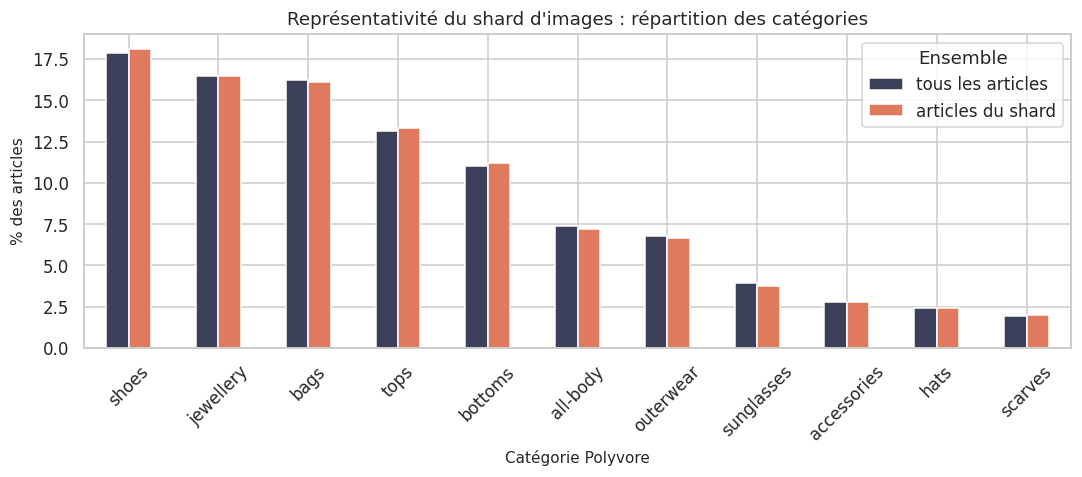

Figure enregistrée : /content/dressme/reports/figures/06_polyvore_representativite_shard.png


In [33]:
if outfits is not None and items is not None:
    coverage = outfits.assign(in_shard=outfits["item_id"].isin(shard_ids)).groupby("set_id")["in_shard"].mean()
    shard_coverage = pd.DataFrame({
        "constat": ["tenues dont tous les articles ont une image", "tenues avec au moins une image", "tenues sans aucune image"],
        "nombre": [int((coverage == 1).sum()), int((coverage > 0).sum()), int((coverage == 0).sum())],
    })
    shard_coverage["pourcentage"] = (100 * shard_coverage["nombre"] / len(coverage)).round(2)
    display(shard_coverage)

    distribution = pd.DataFrame({
        "tous les articles": items["category"].value_counts(normalize=True) * 100,
        "articles du shard": items.loc[items["in_image_shard"], "category"].value_counts(normalize=True) * 100,
    }).fillna(0)
    fig, ax = plt.subplots(figsize=(10, 4.5))
    distribution.plot.bar(ax=ax, color=["#3D405B", "#E07A5F"])
    ax.set_title("Représentativité du shard d'images : répartition des catégories")
    ax.set_xlabel("Catégorie Polyvore")
    ax.set_ylabel("% des articles")
    ax.legend(title="Ensemble")
    ax.tick_params(axis="x", rotation=45)
    save_fig(fig, "06_polyvore_representativite_shard")

**Ce qu'on observe / Ce qu'on en conclut**

*À compléter après exécution, uniquement à partir des sorties ci-dessus :*
- part des tenues entièrement illustrées (limite pour un modèle visuel de compatibilité)
- biais éventuel de catégories dans le shard ; besoin de télécharger d'autres shards ?

## 7. Transformation

**Règles appliquées à toutes les sources**

1. retrait des lignes dont l'image est absente ou illisible ;
2. mapping vers la taxonomie DressMe : `haut, bas, robe, veste, chaussures, sac, accessoire` (+ `hors_perimetre`, retiré) ;
3. normalisation des couleurs en familles (`noir, blanc, gris, beige, marron, rouge, rose, orange, jaune, vert, bleu, violet, multicolore, metallique`, `autre` sinon) ;
4. split train / val / test **stratifié** (≈70/15/15) et **sans fuite** : les éléments d'un même groupe restent
   dans le même split, vérifié par `assert_no_leakage`.

**Pourquoi on fait ça :** Fashion Products : un même produit peut apparaître sous plusieurs `id` avec un nom identique. On regroupe par nom normalisé (`product_group`) pour qu'il ne soit jamais à la fois en train et en test.

In [34]:
cleaning_log = {}


def attach_checks(df, source):
    """Ajoute image_ok / width / height ; sans vérification, on se fie à la présence du fichier."""
    df = df.copy()
    if source in image_checks:
        df = df.join(image_checks[source][["image_ok", "problem", "width", "height"]])
    else:
        df["image_ok"] = np.nan
    fallback = df["image_exists"] if "image_exists" in df else df["image_path"].notna()
    df["image_ok"] = df["image_ok"].fillna(fallback).astype(bool)
    return df


products_clean = None
if products is not None:
    fp = attach_checks(products, "fashion_products")
    steps = {"lignes lues": len(fp)}
    fp["dressme_category"] = preprocessing.map_fashion_products(fp)
    fp["color_family"] = fp["baseColour"].map(preprocessing.normalize_color)
    for column in ("gender", "season", "usage", "baseColour"):
        fp[column] = fp[column].fillna("inconnu")
    fp["color_family"] = fp["color_family"].fillna("inconnu")
    fp["year"] = fp["year"].astype("Int64")
    names = preprocessing.normalize_name(fp["productDisplayName"])
    fp["product_group"] = names.mask(names.eq(""), "id_" + fp["id"].astype(str))

    fp = fp[fp["image_ok"]]
    steps["après retrait des images absentes/illisibles"] = len(fp)
    fp = fp[fp["dressme_category"] != OUT_OF_SCOPE].reset_index(drop=True)
    steps["après retrait des articles hors périmètre"] = len(fp)

    fp["split"] = preprocessing.stratified_split(fp, "dressme_category", group_col="product_group", seed=SEED)
    preprocessing.assert_no_leakage(fp, "split", "id")
    preprocessing.assert_no_leakage(fp, "split", "product_group")
    steps["exclues du split (classe < 10)"] = int((fp["split"] == "exclu").sum())
    cleaning_log["fashion_products"] = steps
    products_clean = fp
    display(pd.Series(steps, name="Fashion Products").to_frame())
    display(pd.crosstab(fp["dressme_category"], fp["split"], margins=True, margins_name="total"))

,Fashion Products
lignes lues,44424
après retrait des images absentes/illisibles,44419
après retrait des articles hors périmètre,38868
exclues du split (classe < 10),0


split,test,train,val,total
dressme_category,,,,
accessoire,1054,5383,1055,7492
bas,435,1873,385,2693
chaussures,1315,6582,1322,9219
haut,2070,10842,2158,15070
robe,170,730,129,1029
sac,454,2151,450,3055
veste,34,223,53,310
total,5532,27784,5552,38868


**Ce qu'on observe / Ce qu'on en conclut**

*À compléter après exécution, uniquement à partir des sorties ci-dessus :*
- nombre de lignes retirées à chaque étape
- répartition des catégories DressMe par split

**Pourquoi on fait ça :** Clothing Full : les photos d'une même personne partagent décor et éclairage. Le split groupé par `sender_id` évite qu'un modèle reconnaisse le décor plutôt que le vêtement.

In [35]:
clothing_clean = None
if clothing is not None:
    cf = attach_checks(clothing, "clothing_full")
    steps = {"lignes lues": len(cf)}
    cf["dressme_category"] = preprocessing.map_clothing_full(cf)
    cf["sender_id"] = cf["sender_id"].astype("string").fillna("img_" + cf["image"].astype(str))
    cf = cf[cf["image_ok"]]
    steps["après retrait des images absentes/illisibles"] = len(cf)
    cf = cf[cf["dressme_category"] != OUT_OF_SCOPE].reset_index(drop=True)
    steps["après retrait hors périmètre (Not sure, Other, Skip, Undershirt)"] = len(cf)

    cf["split"] = preprocessing.stratified_split(cf, "dressme_category", group_col="sender_id", seed=SEED)
    preprocessing.assert_no_leakage(cf, "split", "image")
    preprocessing.assert_no_leakage(cf, "split", "sender_id")
    steps["exclues du split (classe < 10)"] = int((cf["split"] == "exclu").sum())
    cleaning_log["clothing_full"] = steps
    clothing_clean = cf
    display(pd.Series(steps, name="Clothing Full").to_frame())
    display(pd.crosstab(cf["dressme_category"], cf["split"], margins=True, margins_name="total"))

,Clothing Full
lignes lues,5403
après retrait des images absentes/illisibles,5403
"après retrait hors périmètre (Not sure, Other, Skip, Undershirt)",4978
exclues du split (classe < 10),0


split,test,train,val,total
dressme_category,,,,
accessoire,61,103,7,171
bas,256,804,95,1155
chaussures,36,371,24,431
haut,285,1961,128,2374
robe,76,334,16,426
veste,133,273,15,421
total,847,3846,285,4978


**Ce qu'on observe / Ce qu'on en conclut**

*À compléter après exécution, uniquement à partir des sorties ci-dessus :*
- labels exclus (hors périmètre) et effectifs restants
- équilibre des splits

**Pourquoi on fait ça :** Polyvore sert à deux tâches différentes, donc deux découpes : par **article** pour la classification d'attributs, et par **tenue** (`set_id`, découpe officielle) pour la compatibilité et le ranking.

In [36]:
polyvore_items_clean, polyvore_outfits_clean = None, None
if items is not None:
    pi = items.copy()
    if "polyvore_items" in image_checks:
        pi = pi.join(image_checks["polyvore_items"][["image_ok", "width", "height"]])
    else:
        pi["image_ok"] = np.nan
    pi["image_ok"] = pi["image_ok"].fillna(False).astype(bool)   # sans image extraite : pas d'image utilisable
    steps = {"articles": len(pi)}
    pi["text"] = preprocessing.polyvore_text(pi)
    pi["has_text"] = pi["text"] != ""
    pi["dressme_category"] = preprocessing.map_polyvore(pi)
    pi = pi[pi["dressme_category"] != OUT_OF_SCOPE].reset_index(drop=True)
    steps["après retrait hors périmètre"] = len(pi)
    steps["avec image utilisable (échantillon extrait)"] = int(pi["image_ok"].sum())
    # Split au niveau ARTICLE (tâche : classification d'attributs) ; chaque article est unique.
    pi["split"] = preprocessing.stratified_split(pi, "dressme_category", seed=SEED)
    preprocessing.assert_no_leakage(pi, "split", "item_id")
    cleaning_log["polyvore_items"] = steps
    polyvore_items_clean = pi
    display(pd.Series(steps, name="Polyvore items").to_frame())

if outfits is not None:
    po = outfits.copy()
    if polyvore_items_clean is not None:
        po = po.merge(polyvore_items_clean[["item_id", "dressme_category"]], on="item_id", how="left")
        po["dressme_category"] = po["dressme_category"].fillna(OUT_OF_SCOPE)
    po["in_image_shard"] = po["item_id"].isin(shard_ids)
    # Split au niveau TENUE (tâche : compatibilité / ranking) : on garde la découpe officielle, par set_id.
    po["split"] = po["split"].replace({"valid": "val"})
    preprocessing.assert_no_leakage(po, "split", "set_id")
    shared_items = int((po.groupby("item_id")["split"].nunique() > 1).sum())
    cleaning_log["polyvore_outfits"] = {"lignes": len(po), "tenues": int(po["set_id"].nunique()),
                                        "articles_partagés_entre_splits": shared_items}
    polyvore_outfits_clean = po
    display(pd.Series(cleaning_log["polyvore_outfits"], name="Polyvore outfits").to_frame())
    display(po.groupby("split")["set_id"].nunique().to_frame("tenues"))

/tmp/ipykernel_2624/4138753335.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  pi["image_ok"] = pi["image_ok"].fillna(False).astype(bool)   # sans image extraite : pas d'image utilisable


,Polyvore items
articles,251008
après retrait hors périmètre,251008
avec image utilisable (échantillon extrait),5000


,Polyvore outfits
lignes,365054
tenues,68306
articles_partagés_entre_splits,23596


,tenues
split,
test,10000
train,53306
val,5000


**Ce qu'on observe / Ce qu'on en conclut**

*À compléter après exécution, uniquement à partir des sorties ci-dessus :*
- articles avec texte / image utilisables
- nombre d'articles partagés entre splits de tenues (à garder en tête à l'évaluation)

**Pourquoi on fait ça :** on contrôle visuellement que la stratification conserve les mêmes proportions de catégories dans chaque split.

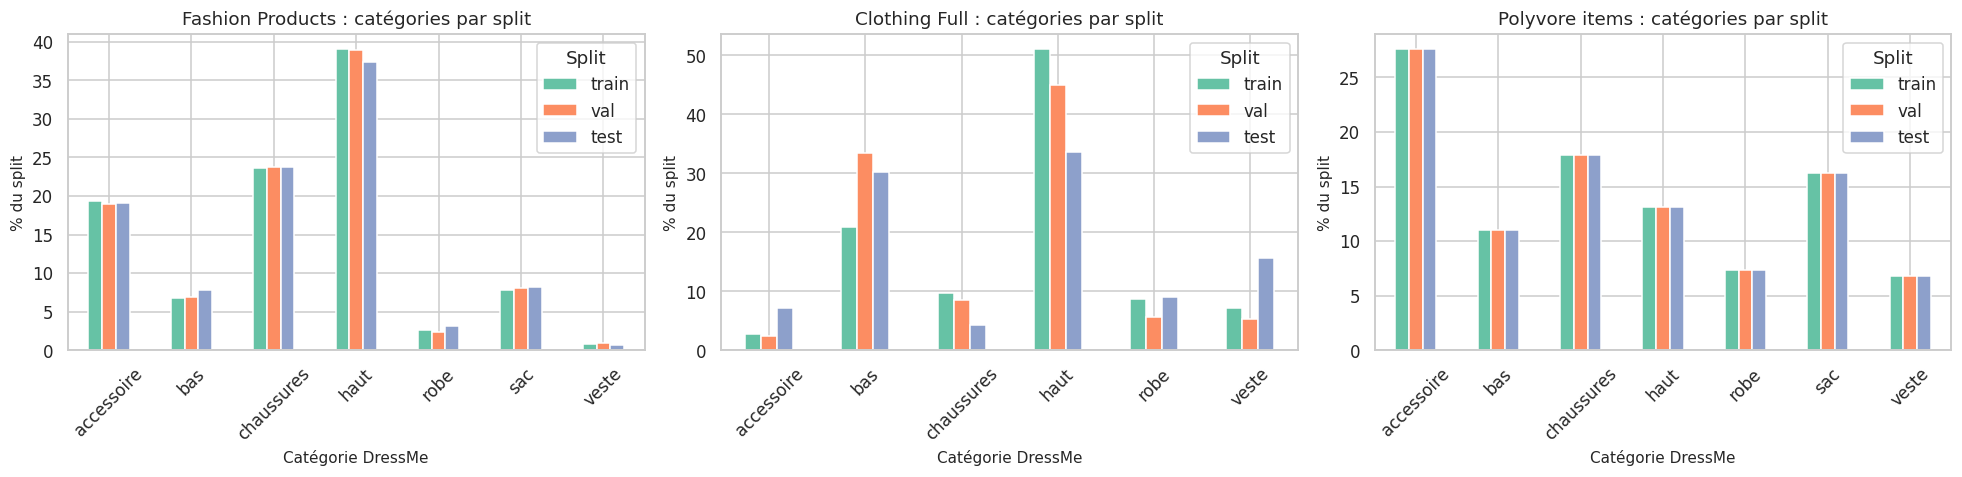

Figure enregistrée : /content/dressme/reports/figures/07_repartition_splits.png


In [37]:
clean_tables = {"Fashion Products": products_clean, "Clothing Full": clothing_clean, "Polyvore items": polyvore_items_clean}
available_tables = {name: df for name, df in clean_tables.items() if df is not None}
if available_tables:
    fig, axes = plt.subplots(1, len(available_tables), figsize=(6 * len(available_tables), 4.5), squeeze=False)
    for ax, (name, df) in zip(axes.flat, available_tables.items()):
        shares = pd.crosstab(df["dressme_category"], df["split"], normalize="columns") * 100
        shares = shares[[c for c in ("train", "val", "test") if c in shares.columns]]
        shares.plot.bar(ax=ax)
        ax.set_title(f"{name} : catégories par split")
        ax.set_xlabel("Catégorie DressMe")
        ax.set_ylabel("% du split")
        ax.legend(title="Split")
        ax.tick_params(axis="x", rotation=45)
    save_fig(fig, "07_repartition_splits")

**Ce qu'on observe / Ce qu'on en conclut**

*À compléter après exécution, uniquement à partir des sorties ci-dessus :*
- proportions similaires ou non entre train, val et test

**Pourquoi on fait ça :** un **catalogue unifié** (une ligne par article avec image, toutes sources confondues) servira au prototype (étape B) et aux embeddings.

In [38]:
catalog_parts = []
if products_clean is not None:
    catalog_parts.append(pd.DataFrame({
        "source": "fashion_products", "item_key": "fp_" + products_clean["id"].astype(str),
        "image_path": products_clean["image_path"], "dressme_category": products_clean["dressme_category"],
        "color_family": products_clean["color_family"], "style": products_clean["usage"],
        "season": products_clean["season"], "split": products_clean["split"]}))
if clothing_clean is not None:
    catalog_parts.append(pd.DataFrame({
        "source": "clothing_full", "item_key": "cf_" + clothing_clean["image"].astype(str),
        "image_path": clothing_clean["image_path"], "dressme_category": clothing_clean["dressme_category"],
        "color_family": None, "style": None, "season": None, "split": clothing_clean["split"]}))
if polyvore_items_clean is not None:
    with_image = polyvore_items_clean[polyvore_items_clean["image_ok"]]
    catalog_parts.append(pd.DataFrame({
        "source": "polyvore", "item_key": "pv_" + with_image["item_id"].astype(str),
        "image_path": with_image["image_path"], "dressme_category": with_image["dressme_category"],
        "color_family": None, "style": None, "season": None, "split": with_image["split"]}))
catalog = pd.concat(catalog_parts, ignore_index=True) if catalog_parts else pd.DataFrame()
print("Catalogue unifié (articles avec image) :", len(catalog))
if len(catalog):
    display(pd.crosstab(catalog["dressme_category"], catalog["source"], margins=True, margins_name="total"))

Catalogue unifié (articles avec image) : 48846


source,clothing_full,fashion_products,polyvore,total
dressme_category,,,,
accessoire,171,7492,1364,9027
bas,1155,2693,549,4397
chaussures,431,9219,947,10597
haut,2374,15070,655,18099
robe,426,1029,338,1793
sac,0,3055,802,3857
veste,421,310,345,1076
total,4978,38868,5000,48846


**Ce qu'on observe / Ce qu'on en conclut**

*À compléter après exécution, uniquement à partir des sorties ci-dessus :*
- contribution de chaque source à chaque catégorie DressMe

**Pourquoi on fait ça :** on exporte les tables nettoyées en parquet (format compact et typé) dans `data/processed/`, avec un `metadata.json` qui documente règles, effectifs et versions pour la reproductibilité.

In [39]:
from datetime import datetime, timezone

import transformers

exports = {"fashion_products_clean": products_clean, "clothing_full_clean": clothing_clean,
           "polyvore_items_clean": polyvore_items_clean, "polyvore_outfits_clean": polyvore_outfits_clean,
           "dressme_catalog": catalog if len(catalog) else None}
tables_meta = {}
for name, df in exports.items():
    if df is None:
        print(f"{name} : non exporté (source absente)")
        continue
    path = PROCESSED_DIR / f"{name}.parquet"
    df.to_parquet(path, index=False)
    tables_meta[name] = {"file": path.name, "rows": len(df), "columns": list(df.columns),
                         "split_counts": df["split"].value_counts().to_dict() if "split" in df else {}}
    print(f"{name} : {len(df)} lignes -> {path}")

metadata = {
    "created_at": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "environment": ENV, "seed": SEED,
    "taxonomy": DRESSME_CATEGORIES + [OUT_OF_SCOPE],
    "color_families": list(preprocessing.COLOR_FAMILIES),
    "split_policy": {
        "fashion_products": "stratifié par dressme_category, groupé par product_group (nom normalisé)",
        "clothing_full": "stratifié par dressme_category, groupé par sender_id",
        "polyvore_items": "stratifié par dressme_category, un article = un split",
        "polyvore_outfits": "découpe officielle nondisjoint, par set_id",
    },
    "polyvore_image_shard": POLYVORE_SHARD.name if POLYVORE_SHARD else None,
    "polyvore_items_in_shard": len(shard_ids),
    "polyvore_images_extracted": int(len(polyvore_images)),
    "cleaning_log": cleaning_log,
    "tables": tables_meta,
    "versions": {"pandas": pd.__version__, "numpy": np.__version__, "torch": torch.__version__,
                 "transformers": transformers.__version__},
}
(PROCESSED_DIR / "metadata.json").write_text(json.dumps(metadata, ensure_ascii=False, indent=2, default=str), encoding="utf-8")
print("metadata.json écrit dans", PROCESSED_DIR)

fashion_products_clean : 38868 lignes -> /content/dressme/data/processed/fashion_products_clean.parquet
clothing_full_clean : 4978 lignes -> /content/dressme/data/processed/clothing_full_clean.parquet
polyvore_items_clean : 251008 lignes -> /content/dressme/data/processed/polyvore_items_clean.parquet
polyvore_outfits_clean : 365054 lignes -> /content/dressme/data/processed/polyvore_outfits_clean.parquet
dressme_catalog : 48846 lignes -> /content/dressme/data/processed/dressme_catalog.parquet
metadata.json écrit dans /content/dressme/data/processed


**Ce qu'on observe / Ce qu'on en conclut**

*À compléter après exécution, uniquement à partir des sorties ci-dessus :*
- tables exportées et leurs effectifs

## 8. Premier test d'embeddings (FashionCLIP)

**Pourquoi on fait ça :** on vérifie que FashionCLIP produit des représentations utiles **avant** de construire le prototype. L'échantillon est réparti équitablement entre les sources disponibles (`FASHIONCLIP_SAMPLE` : 2000 images sur GPU, 500 sans).

In [40]:
embedding_sample = pd.DataFrame()
if len(catalog):
    candidates = catalog[catalog["image_path"].notna() & catalog["dressme_category"].isin(DRESSME_CATEGORIES)]
    per_source = FASHIONCLIP_SAMPLE // max(candidates["source"].nunique(), 1)
    embedding_sample = pd.concat(
        [group.sample(min(len(group), per_source), random_state=SEED) for _, group in candidates.groupby("source")],
        ignore_index=True,
    )
    display(pd.crosstab(embedding_sample["dressme_category"], embedding_sample["source"], margins=True, margins_name="total"))
else:
    print("Catalogue vide : pas d'échantillon pour FashionCLIP.")

source,clothing_full,fashion_products,polyvore,total
dressme_category,,,,
accessoire,22,130,186,338
bas,142,38,77,257
chaussures,47,159,109,315
haut,331,278,96,705
robe,61,14,46,121
sac,0,42,102,144
veste,63,5,50,118
total,666,666,666,1998


**Ce qu'on observe / Ce qu'on en conclut**

*À compléter après exécution, uniquement à partir des sorties ci-dessus :*
- taille réelle de l'échantillon par source et par catégorie

**Pourquoi on fait ça :** calcul des embeddings (vecteurs normalisés, dimension de projection du modèle). Ils sont sauvegardés et réutilisés à la prochaine session (depuis Drive) ; le temps de calcul est mesuré.

In [41]:
EMB_PATH = EMB_DIR / f"fashionclip_sample_{FASHIONCLIP_SAMPLE}.npz"
SAMPLE_PATH = EMB_DIR / f"fashionclip_sample_{FASHIONCLIP_SAMPLE}.parquet"
FORCE_RECOMPUTE = False  # True pour recalculer même si des embeddings existent (Drive)

model, processor, device = features.load_fashionclip(DEVICE)
vectors = None
if EMB_PATH.exists() and SAMPLE_PATH.exists() and not FORCE_RECOMPUTE:
    vectors, embedded_keys = features.load_embeddings(EMB_PATH)
    embedding_sample = pd.read_parquet(SAMPLE_PATH)
    print(f"Embeddings repris depuis {EMB_PATH} : {vectors.shape}")
elif len(embedding_sample):
    started = time.time()
    vectors, kept = features.embed_images(embedding_sample["image_path"], model, processor, device,
                                          batch_size=64 if device == "cuda" else 16)
    elapsed = time.time() - started
    embedding_sample = embedding_sample.iloc[kept].reset_index(drop=True)
    features.save_embeddings(EMB_PATH, vectors, embedding_sample["item_key"].tolist())
    embedding_sample.to_parquet(SAMPLE_PATH, index=False)
    print(f"{len(vectors)} images embeddées en {elapsed:.0f} s ({1000 * elapsed / max(len(vectors), 1):.1f} ms/image), "
          f"dimension {vectors.shape[1]}")
if vectors is not None:
    assert len(vectors) == len(embedding_sample)

config.json:   0%|          | 0.00/4.46k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Embeddings repris depuis /content/dressme/data/embeddings/fashionclip_sample_2000.npz : (1998, 512)


**Ce qu'on observe / Ce qu'on en conclut**

*À compléter après exécution, uniquement à partir des sorties ci-dessus :*
- temps de calcul réel par image sur T4
- nombre d'images effectivement embeddées

**Pourquoi on fait ça :** une projection 2D (UMAP) montre si les images se regroupent par catégorie (bon signe pour la similarité) ou par source (signe d'un écart studio / photo amateur).

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


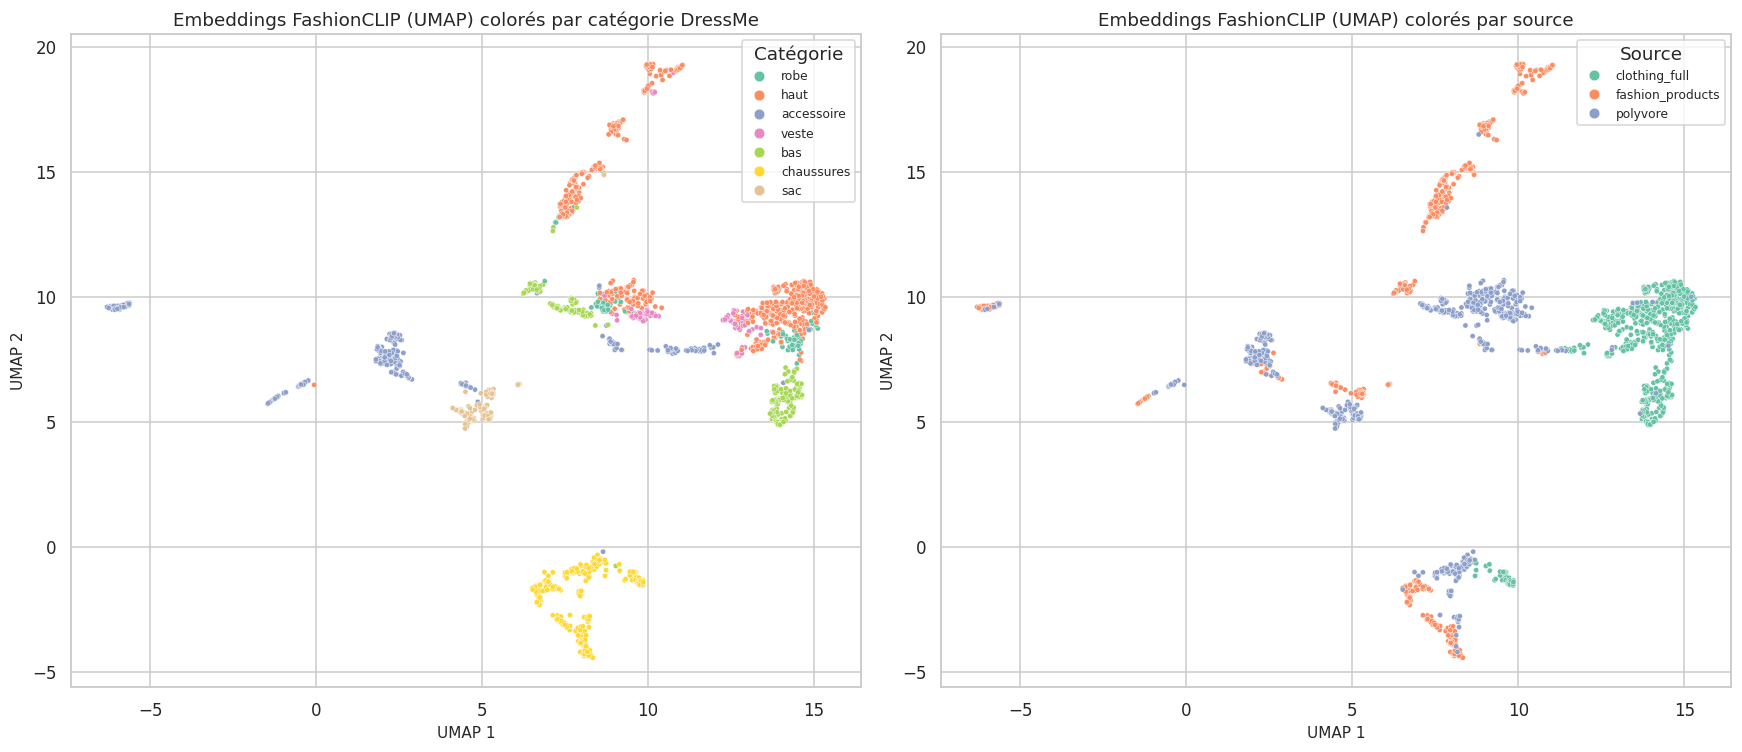

Figure enregistrée : /content/dressme/reports/figures/08_embeddings_umap.png


In [42]:
if vectors is not None and len(vectors) > 10:
    coords, method = features.project_2d(vectors, method="umap", seed=SEED)
    embedding_sample["x"], embedding_sample["y"] = coords[:, 0], coords[:, 1]
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    sns.scatterplot(data=embedding_sample, x="x", y="y", hue="dressme_category", s=12, ax=axes[0])
    axes[0].set_title(f"Embeddings FashionCLIP ({method}) colorés par catégorie DressMe")
    sns.scatterplot(data=embedding_sample, x="x", y="y", hue="source", s=12, ax=axes[1])
    axes[1].set_title(f"Embeddings FashionCLIP ({method}) colorés par source")
    for ax, legend_title in zip(axes, ("Catégorie", "Source")):
        ax.set_xlabel(f"{method} 1")
        ax.set_ylabel(f"{method} 2")
        ax.legend(title=legend_title, markerscale=2, fontsize=8)
    save_fig(fig, "08_embeddings_umap")

**Ce qu'on observe / Ce qu'on en conclut**

*À compléter après exécution, uniquement à partir des sorties ci-dessus :*
- les groupes suivent-ils les catégories ou les sources ?
- catégories qui se mélangent

**Pourquoi on fait ça :** la recherche des 5 plus proches voisins est exactement ce que fera `GET /similar` dans le prototype. On mesure aussi la **precision@5** (part des voisins de même catégorie) et la part de voisins issus de la même source.

,precision@5_categorie,voisins_meme_source
source,,
clothing_full,0.868,0.992
fashion_products,0.960,0.979
polyvore,0.915,0.913
global,0.914,0.961


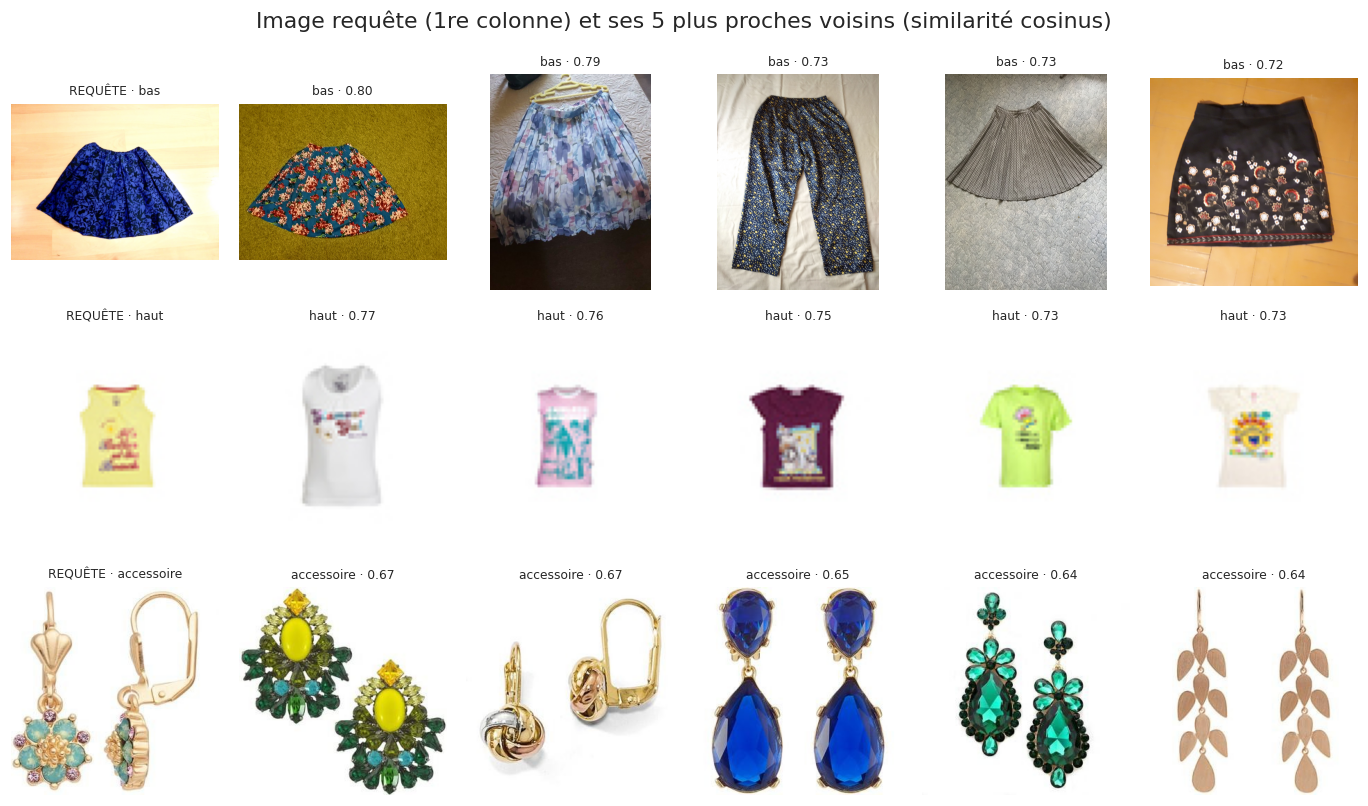

Figure enregistrée : /content/dressme/reports/figures/08_similarite_top5.png


In [43]:
if vectors is not None and len(vectors) > 10:
    similarity = vectors @ vectors.T
    np.fill_diagonal(similarity, -np.inf)
    neighbours = np.argpartition(-similarity, 5, axis=1)[:, :5]
    categories = embedding_sample["dressme_category"].to_numpy()
    source_array = embedding_sample["source"].to_numpy()
    same_category = (categories[neighbours] == categories[:, None]).mean(axis=1)
    same_source = (source_array[neighbours] == source_array[:, None]).mean(axis=1)
    retrieval = pd.DataFrame({"source": source_array, "precision@5_categorie": same_category,
                              "voisins_meme_source": same_source}).groupby("source").mean().round(3)
    retrieval.loc["global"] = [same_category.mean().round(3), same_source.mean().round(3)]
    display(retrieval)

    query_rng = np.random.default_rng(SEED)
    queries = [int(query_rng.choice(np.flatnonzero(source_array == s))) for s in pd.unique(source_array)]
    samples = []
    for query in queries:
        order, scores = features.top_k_similar(vectors[query], vectors, k=5, exclude_index=query)
        samples.append((embedding_sample.loc[query, "image_path"], f"REQUÊTE · {categories[query]}"))
        samples += [(embedding_sample.loc[i, "image_path"], f"{categories[i]} · {score:.2f}") for i, score in zip(order, scores)]
    image_grid(samples, "Image requête (1re colonne) et ses 5 plus proches voisins (similarité cosinus)",
               "08_similarite_top5", n_cols=6)

**Ce qu'on observe / Ce qu'on en conclut**

*À compléter après exécution, uniquement à partir des sorties ci-dessus :*
- precision@5 par source et globale
- les voisins restent-ils dans la même source ? (écart de domaine)
- qualité visuelle des voisins sur les exemples

**Pourquoi on fait ça :** la classification zero-shot (sans entraînement) donne une première mesure de l'extraction d'attributs (obj. 1) : catégorie sur toutes les sources, couleur et style sur Fashion Products (seule source avec vérité terrain pour ces attributs). La matière n'a pas de vérité terrain : elle n'est pas évaluée.

,attribut,périmètre,n,accuracy,f1_macro
0,catégorie,toutes sources,1998,0.897,0.872
1,catégorie,clothing_full,666,0.901,0.758
2,catégorie,fashion_products,666,0.871,0.761
3,catégorie,polyvore,666,0.920,0.914
4,couleur,fashion_products,658,0.725,0.683
5,style (usage),fashion_products,666,0.432,0.215


              precision    recall  f1-score   support

        haut       0.96      0.88      0.91       705
         bas       0.93      0.98      0.96       257
        robe       0.66      0.82      0.73       121
       veste       0.70      0.93      0.80       118
  chaussures       0.96      1.00      0.98       315
         sac       0.77      1.00      0.87       144
  accessoire       0.99      0.75      0.85       338

    accuracy                           0.90      1998
   macro avg       0.85      0.91      0.87      1998
weighted avg       0.91      0.90      0.90      1998



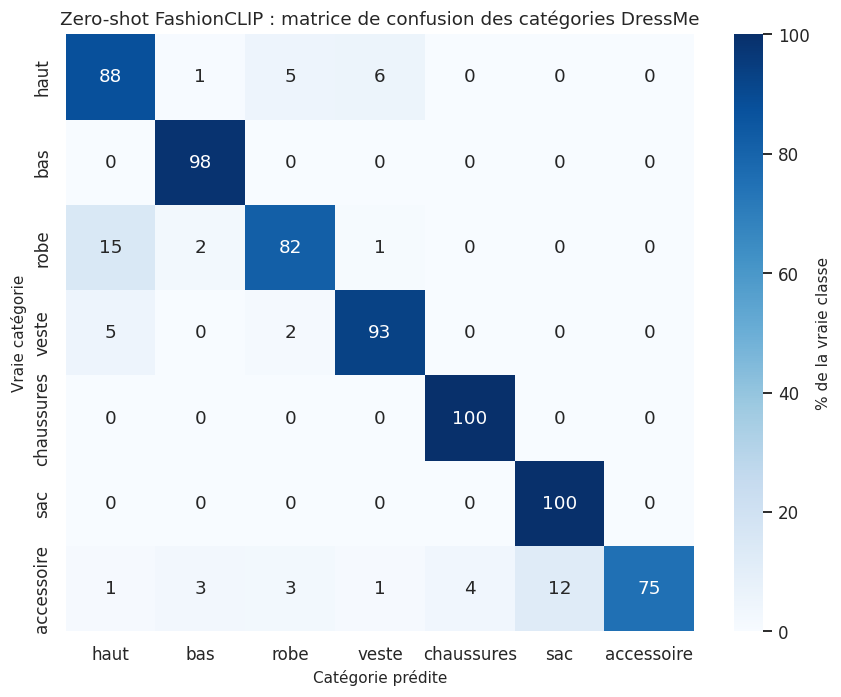

Figure enregistrée : /content/dressme/reports/figures/08_zero_shot_confusion.png


In [44]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

if vectors is not None and len(vectors):
    category_labels = list(features.DRESSME_CATEGORY_PROMPTS)
    predicted, _ = features.zero_shot(vectors, list(features.DRESSME_CATEGORY_PROMPTS.values()), model, processor,
                                      device, template="a photo of {}")
    embedding_sample["zero_shot_category"] = [category_labels[i] for i in predicted]
    truth, guess = embedding_sample["dressme_category"], embedding_sample["zero_shot_category"]

    zs_rows = [{"attribut": "catégorie", "périmètre": "toutes sources", "n": len(truth),
                "accuracy": round(accuracy_score(truth, guess), 3),
                "f1_macro": round(f1_score(truth, guess, average="macro"), 3)}]
    for source, group in embedding_sample.groupby("source"):
        zs_rows.append({"attribut": "catégorie", "périmètre": source, "n": len(group),
                        "accuracy": round(accuracy_score(group["dressme_category"], group["zero_shot_category"]), 3),
                        "f1_macro": round(f1_score(group["dressme_category"], group["zero_shot_category"], average="macro"), 3)})

    products_part = embedding_sample[embedding_sample["source"] == "fashion_products"]
    for attribute, column, prompts, template in (
        ("couleur", "color_family", features.COLOR_PROMPTS, "a photo of a {} clothing item"),
        ("style (usage)", "style", features.STYLE_PROMPTS, "a photo of a {} fashion item"),
    ):
        subset = products_part[products_part[column].isin(prompts)]
        if len(subset) < 10:
            continue
        labels = list(prompts)
        predicted_attr, _ = features.zero_shot(vectors[subset.index.to_numpy()], list(prompts.values()), model,
                                               processor, device, template=template)
        guess_attr = [labels[i] for i in predicted_attr]
        zs_rows.append({"attribut": attribute, "périmètre": "fashion_products", "n": len(subset),
                        "accuracy": round(accuracy_score(subset[column], guess_attr), 3),
                        "f1_macro": round(f1_score(subset[column], guess_attr, average="macro"), 3)})
    zero_shot_results = pd.DataFrame(zs_rows)
    display(zero_shot_results)
    zero_shot_results.to_csv(PROCESSED_DIR / "zero_shot_results.csv", index=False)

    print(classification_report(truth, guess, labels=category_labels, zero_division=0))
    matrix = confusion_matrix(truth, guess, labels=category_labels, normalize="true") * 100
    fig, ax = plt.subplots(figsize=(8, 6.5))
    sns.heatmap(matrix, annot=True, fmt=".0f", cmap="Blues", xticklabels=category_labels,
                yticklabels=category_labels, ax=ax, cbar_kws={"label": "% de la vraie classe"})
    ax.set_title("Zero-shot FashionCLIP : matrice de confusion des catégories DressMe")
    ax.set_xlabel("Catégorie prédite")
    ax.set_ylabel("Vraie catégorie")
    save_fig(fig, "08_zero_shot_confusion")
    embedding_sample.drop(columns=["x", "y"], errors="ignore").to_parquet(SAMPLE_PATH, index=False)

**Ce qu'on observe / Ce qu'on en conclut**

*À compléter après exécution, uniquement à partir des sorties ci-dessus :*
- accuracy et F1 macro réels par attribut et par source
- confusions principales (ex. veste / haut)
- attributs pour lesquels le zero-shot suffit, et ceux qui demandent un fine-tuning

## 9. Synthèse

*À compléter après exécution, uniquement à partir des résultats ci-dessus.* La colonne « Données disponibles »
décrit le contenu des sources (fait établi par leur schéma) ; les deux autres colonnes sont à remplir.

| Data Science Objective | Données disponibles | Ce que les données permettent (constat) | Ce qu'elles ne permettent pas |
|---|---|---|---|
| 1. Extraction d'attributs | catégorie (3 sources), couleur / saison / usage (Fashion Products) ; aucune colonne « matière » | À compléter | À compléter |
| 2. Embeddings et similarité | images des 3 sources (Polyvore limité au shard) | À compléter (precision@5, UMAP) | À compléter |
| 3. Profil utilisateur dynamique | aucune donnée d'utilisateur ni d'interaction | À compléter | À compléter |
| 4. Contexte | `season`, `usage` (Fashion Products) ; aucune donnée météo | À compléter | À compléter |
| 5. Ranking de tenues | 68 306 tenues Polyvore | À compléter | À compléter |
| 6. Wardrobe gap | combinaisons de catégories des tenues Polyvore | À compléter | À compléter |

**Risques à évaluer avec les chiffres obtenus**

- **Biais** de la population représentée (genre, style, marché d'origine des catalogues) : À compléter.
- **Déséquilibre des classes** (voir section 4) : À compléter.
- **Photos studio contre photos utilisateur** : écart de domaine mesuré en section 8 : À compléter.
- **Absence de données tunisiennes** (tenues, climat, pratiques vestimentaires locales) : À compléter.
- **Couverture d'images Polyvore** (un shard sur six) : À compléter.

**Prochaines étapes** : À compléter (ex. télécharger d'autres shards, fine-tuning, données utilisateur simulées).

## 10. Sauvegarde vers Google Drive

**Pourquoi on fait ça :** les fichiers de `/content` disparaissent à la fin de la session. On copie tables (`data/processed/`), embeddings, figures et code vers `Drive/dressme_outputs`. Le notebook 02 (prototype) repartira de là.

In [45]:
backup_to_drive(include_raw=False)
if DRIVE_DIR is not None:
    for folder in ("processed", "embeddings", "figures"):
        files = sorted((DRIVE_DIR / folder).glob("*"))
        size_mb = sum(f.stat().st_size for f in files if f.is_file()) / 1e6
        print(f"{folder:<11} {len(files):>3} fichiers, {size_mb:.1f} Mo")

Sauvegardé dans : /content/drive/MyDrive/dressme_outputs
processed     8 fichiers, 24.1 Mo
embeddings    2 fichiers, 3.8 Mo
figures      19 fichiers, 5.8 Mo


**Ce qu'on observe / Ce qu'on en conclut**

*À compléter après exécution, uniquement à partir des sorties ci-dessus :*
- fichiers présents sur Drive et leur taille